 1. Setup & Load 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import (RobustScaler, LabelEncoder,
                                         MinMaxScaler, label_binarize)
from sklearn.feature_selection  import VarianceThreshold
from sklearn.pipeline           import Pipeline
from sklearn.compose            import ColumnTransformer
from imblearn.pipeline          import Pipeline as ImbPipeline

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams.update({'axes.titlesize':11, 'axes.labelsize':10})
print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
df = pd.read_csv("combinenew.csv",low_memory=False)
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3.0000,2.0000,0.0000,12.0000,0.0000,6.0000,6.0000,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,4000000.0000,666666.6667,3.0000,0.0000,3.0000,3.0000,3.0000,3.0000,0.0000,3.0000,3.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,40.0000,0.0000,666666.6667,0.0000,6.0000,6.0000,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,9.0000,6.0000,0.0000,40.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,12.0000,0.0000,0.0000,33.0000,-1.0000,1.0000,20.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,BENIGN
1,55054,109.0000,1.0000,1.0000,6.0000,6.0000,6.0000,6.0000,6.0000,0.0000,6.0000,6.0000,6.0000,0.0000,110091.7431,18348.6238,109.0000,0.0000,109.0000,109.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,20.0000,20.0000,9174.3119,9174.3119,6.0000,6.0000,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,9.0000,6.0000,6.0000,20.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,6.0000,1.0000,6.0000,29.0000,256.0000,0.0000,20.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,BENIGN
2,55055,52.0000,1.0000,1.0000,6.0000,6.0000,6.0000,6.0000,6.0000,0.0000,6.0000,6.0000,6.0000,0.0000,230769.2308,38461.5385,52.0000,0.0000,52.0000,52.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,20.0000,20.0000,19230.7692,19230.7692,6.0000,6.0000,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,9.0000,6.0000,6.0000,20.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,6.0000,1.0000,6.0000,29.0000,256.0000,0.0000,20.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,BENIGN
3,46236,34.0000,1.0000,1.0000,6.0000,6.0000,6.0000,6.0000,6.0000,0.0000,6.0000,6.0000,6.0000,0.0000,352941.1765,58823.5294,34.0000,0.0000,34.0000,34.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,20.0000,20.0000,29411.7647,29411.7647,6.0000,6.0000,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,9.0000,6.0000,6.0000,20.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,6.0000,1.0000,6.0000,31.0000,329.0000,0.0000,20.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,BENIGN
4,54863,3.0000,2.0000,0.0000,12.0000,0.0000,6.0000,6.0000,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,4000000.0000,666666.6667,3.0000,0.0000,3.0000,3.0000,3.0000,3.0000,0.0000,3.0000,3.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,40.0000,0.0000,666666.6667,0.0000,6.0000,6.0000,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.

In [3]:
def class_name(le, idx):
    return str(le.classes_[int(idx)])

In [4]:
# removing white space
df.columns = df.columns.str.strip()

2. Drop Zero-Variance & Duplicate Columns
   
Remove features that carry no information before any other step.

In [5]:
# ── 2a. Drop known CICIDS2017 duplicate column
if 'Fwd Header Length.1' in df.columns:
    df.drop(columns=['Fwd Header Length.1'], inplace=True)
    print('✅ Dropped: Fwd Header Length.1 (exact duplicate of Fwd Header Length)')
else:
    print('ℹ️  Fwd Header Length.1 not present (already cleaned)')

✅ Dropped: Fwd Header Length.1 (exact duplicate of Fwd Header Length)


In [6]:
# ── 2b. Drop non-feature identifier columns
ID_COLS = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'source_file']
id_present = [c for c in ID_COLS if c in df.columns]
df.drop(columns=id_present, inplace=True)
print(f'Dropped identifier columns: {id_present}')

Dropped identifier columns: []


In [7]:
# ── 2c. Drop zero-variance columns (std == 0)
EXCLUDE = ['Label']
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in EXCLUDE]

zero_var_cols = [c for c in num_cols if df[c].std() == 0]
print(f'Zero-variance columns found ({len(zero_var_cols)}): {zero_var_cols}')

if zero_var_cols:
    df.drop(columns=zero_var_cols, inplace=True)
    print(f'✅ Dropped {len(zero_var_cols)} zero-variance column(s)')

print(f'Shape after cleanup: {df.shape}')

Zero-variance columns found (8): ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
✅ Dropped 8 zero-variance column(s)
Shape after cleanup: (2830744, 70)


3. Handle Infinity & Missing Values 

In [8]:
# ── 3a. Replace Inf / -Inf with NaN
num_cols = df.select_dtypes(include=np.number).columns
inf_counts = np.isinf(df[num_cols]).sum()
total_inf = inf_counts.sum()
print(f'Total Inf values: {total_inf:,}')
if total_inf > 0:
    print('Affected columns:')
    print(inf_counts[inf_counts > 0])

df.replace([np.inf, -np.inf], np.nan, inplace=True)
print('✅ Inf values replaced with NaN')


Total Inf values: 4,312
Affected columns:
Flow Bytes/s      1479
Flow Packets/s    2833
dtype: int64
✅ Inf values replaced with NaN


In [9]:
# ── 3b. Summarise missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'Columns with missing values: {len(missing)}')
if len(missing):
    print(missing)

# ── 3c. Strategy: drop rows with NaN
# (NaN here only comes from Inf replacement — very few rows)
before = len(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'\nRows removed by dropna: {before - len(df):,}  ({(before-len(df))/before*100:.3f}%)')
print(f'Shape after NaN removal: {df.shape}')

Columns with missing values: 69
Flow Bytes/s            2838
Flow Packets/s          2834
Flow Duration              1
Subflow Fwd Packets        1
Avg Fwd Segment Size       1
                        ... 
Fwd URG Flags              1
Fwd Header Length          1
Bwd Header Length          1
Fwd Packets/s              1
Label                      1
Length: 69, dtype: int64

Rows removed by dropna: 2,838  (0.100%)
Shape after NaN removal: (2827906, 70)


 4. Drop Duplicate Rows

In [10]:
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
removed = before - len(df)
print(f'Duplicate rows removed : {removed:,}  ({removed/before*100:.2f}%)')
print(f'Shape after dedup      : {df.shape}')


Duplicate rows removed : 329,663  (11.66%)
Shape after dedup      : (2498243, 70)


In [11]:
def safe_col(df, col):
    """Return column if it exists, else a zero Series."""
    return df[col] if col in df.columns else pd.Series(0, index=df.index)

# ── 5a. Traffic Direction Asymmetry
fwd = safe_col(df, 'Total Fwd Packets')
bwd = safe_col(df, 'Total Backward Packets')
df['Fwd_Bwd_Pkt_Ratio'] = fwd / (fwd + bwd + 1)
print('✅ Fwd_Bwd_Pkt_Ratio created')

# ── 5b. Average bytes per packet
flow_bytes   = safe_col(df, 'Flow Bytes/s')
flow_packets = safe_col(df, 'Flow Packets/s')
df['Bytes_Per_Packet'] = flow_bytes / (flow_packets + 1)
print('✅ Bytes_Per_Packet created')

# ── 5c. Header-to-payload ratio (forward direction)
fwd_hdr  = safe_col(df, 'Fwd Header Length')
fwd_len  = safe_col(df, 'Total Length of Fwd Packets')
df['Header_Payload_Ratio'] = fwd_hdr / (fwd_len + 1)
print('✅ Header_Payload_Ratio created')

# ── 5d. IAT asymmetry between directions
fwd_iat = safe_col(df, 'Fwd IAT Mean')
bwd_iat = safe_col(df, 'Bwd IAT Mean')
df['IAT_Fwd_Bwd_Ratio'] = fwd_iat / (bwd_iat + 1)
print('✅ IAT_Fwd_Bwd_Ratio created')

# ── 5e. Binary TCP flag indicators
for flag, src in [('Has_SYN','SYN Flag Count'),
                  ('Has_RST','RST Flag Count'),
                  ('Has_FIN','FIN Flag Count')]:
    if src in df.columns:
        df[flag] = (df[src] > 0).astype(int)
        print(f'✅ {flag} created')

# ── 5f. Packet size asymmetry
fwd_pkt_mean = safe_col(df, 'Fwd Packet Length Mean')
bwd_pkt_mean = safe_col(df, 'Bwd Packet Length Mean')
df['Pkt_Size_Asymmetry'] = fwd_pkt_mean - bwd_pkt_mean
print('✅ Pkt_Size_Asymmetry created')

# ── 5g. TCP window size ratio
win_fwd = safe_col(df, 'Init_Win_bytes_forward')
win_bwd = safe_col(df, 'Init_Win_bytes_backward')
df['Win_Size_Ratio'] = win_fwd / (win_bwd.abs() + 1)
print('✅ Win_Size_Ratio created')

print(f'\nNew feature count: 10 | Total columns now: {df.shape[1]}')

✅ Fwd_Bwd_Pkt_Ratio created
✅ Bytes_Per_Packet created
✅ Header_Payload_Ratio created
✅ IAT_Fwd_Bwd_Ratio created
✅ Has_SYN created
✅ Has_RST created
✅ Has_FIN created
✅ Pkt_Size_Asymmetry created
✅ Win_Size_Ratio created

New feature count: 10 | Total columns now: 79


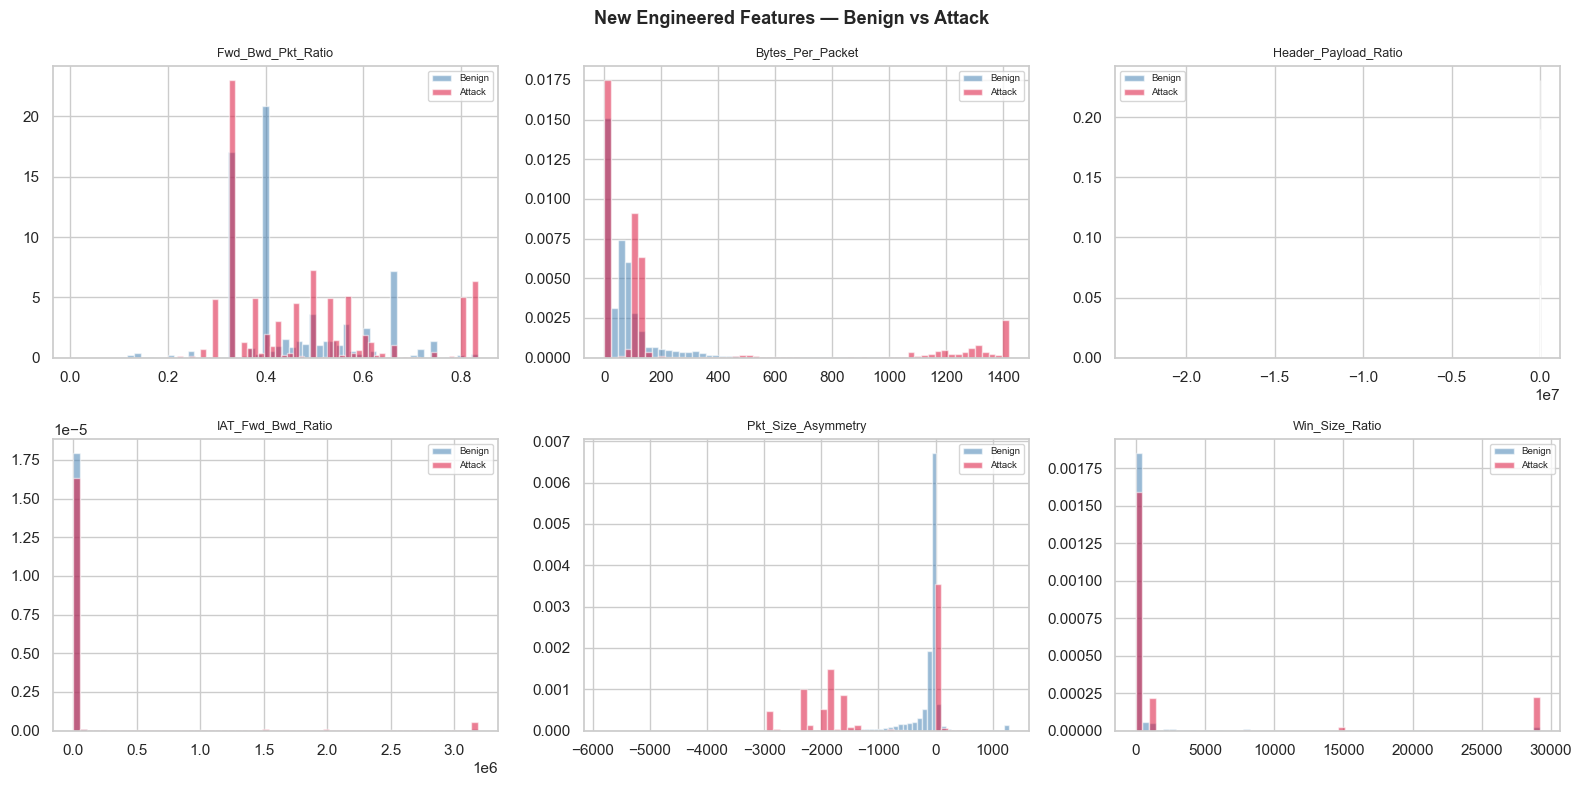

In [12]:
# ── Visualise distributions of new features
new_feats = ['Fwd_Bwd_Pkt_Ratio','Bytes_Per_Packet','Header_Payload_Ratio',
             'IAT_Fwd_Bwd_Ratio','Pkt_Size_Asymmetry','Win_Size_Ratio']
new_feats = [f for f in new_feats if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(new_feats):
    s = df[feat].replace([np.inf,-np.inf], np.nan).dropna()
    q99 = s.quantile(0.99)
    s = s.clip(upper=q99)
    benign_s = df.loc[df['Label']=='BENIGN', feat].clip(upper=q99)
    attack_s = df.loc[df['Label']!='BENIGN', feat].clip(upper=q99)
    axes[i].hist(benign_s, bins=60, alpha=0.55, color='steelblue',
                 label='Benign', density=True)
    axes[i].hist(attack_s, bins=60, alpha=0.55, color='crimson',
                 label='Attack', density=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=7)
plt.suptitle('New Engineered Features — Benign vs Attack', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.show()


6. Log Transformation for Skewed Features

Apply `log1p(x)` to right-skewed numeric features. This is critical for non-tree models (Logistic Regression, SVM, KNN).
    
Tree-based models (Random Forest, XGBoost) are scale/skew invariant, but it still helps stability.

In [13]:
# ── Identify skewed features: |skewness| > 1 and zero% < 50
num_cols_now = [c for c in df.select_dtypes(include=np.number).columns
                if c not in ['Label','Is_Attack','Has_SYN','Has_RST','Has_FIN']]

skew_series = df[num_cols_now].skew().abs().sort_values(ascending=False)
zero_pct    = (df[num_cols_now] == 0).mean() * 100

LOG_CANDIDATES = skew_series[
    (skew_series > 1) & (zero_pct < 50)
].index.tolist()

print(f'Features selected for log1p transform: {len(LOG_CANDIDATES)}')
print(LOG_CANDIDATES)


Features selected for log1p transform: 50
['Fwd Header Length', 'Header_Payload_Ratio', 'Total Length of Fwd Packets', 'Subflow Fwd Bytes', 'Bwd Header Length', 'min_seg_size_forward', 'act_data_pkt_fwd', 'Total Backward Packets', 'Subflow Bwd Packets', 'Subflow Fwd Packets', 'Total Fwd Packets', 'Subflow Bwd Bytes', 'Total Length of Bwd Packets', 'Flow Bytes/s', 'Flow IAT Min', 'Bwd Packets/s', 'IAT_Fwd_Bwd_Ratio', 'Fwd Packet Length Min', 'Down/Up Ratio', 'Min Packet Length', 'Bwd IAT Min', 'Fwd Packet Length Max', 'Fwd IAT Min', 'Avg Fwd Segment Size', 'Fwd Packet Length Mean', 'Flow IAT Mean', 'Bwd IAT Mean', 'Fwd Packets/s', 'Flow Packets/s', 'Fwd IAT Mean', 'Win_Size_Ratio', 'Packet Length Variance', 'Init_Win_bytes_backward', 'Bwd IAT Max', 'Bytes_Per_Packet', 'Flow IAT Std', 'Bwd Packet Length Max', 'Fwd IAT Max', 'Flow IAT Max', 'Packet Length Std', 'Bwd IAT Total', 'Max Packet Length', 'Init_Win_bytes_forward', 'Bwd Packet Length Mean', 'Avg Bwd Segment Size', 'Average Packet

In [14]:
# ── Apply log1p (clip negatives to 0 first — flow metrics can't be negative)
LOG_COLS = []
for feat in LOG_CANDIDATES:
    if feat in df.columns:
        new_name = f'log_{feat}'
        df[new_name] = np.log1p(df[feat].clip(lower=0))
        LOG_COLS.append(new_name)

print(f'✅ Created {len(LOG_COLS)} log-transformed columns')
print('Sample:', LOG_COLS[:5])


✅ Created 50 log-transformed columns
Sample: ['log_Fwd Header Length', 'log_Header_Payload_Ratio', 'log_Total Length of Fwd Packets', 'log_Subflow Fwd Bytes', 'log_Bwd Header Length']


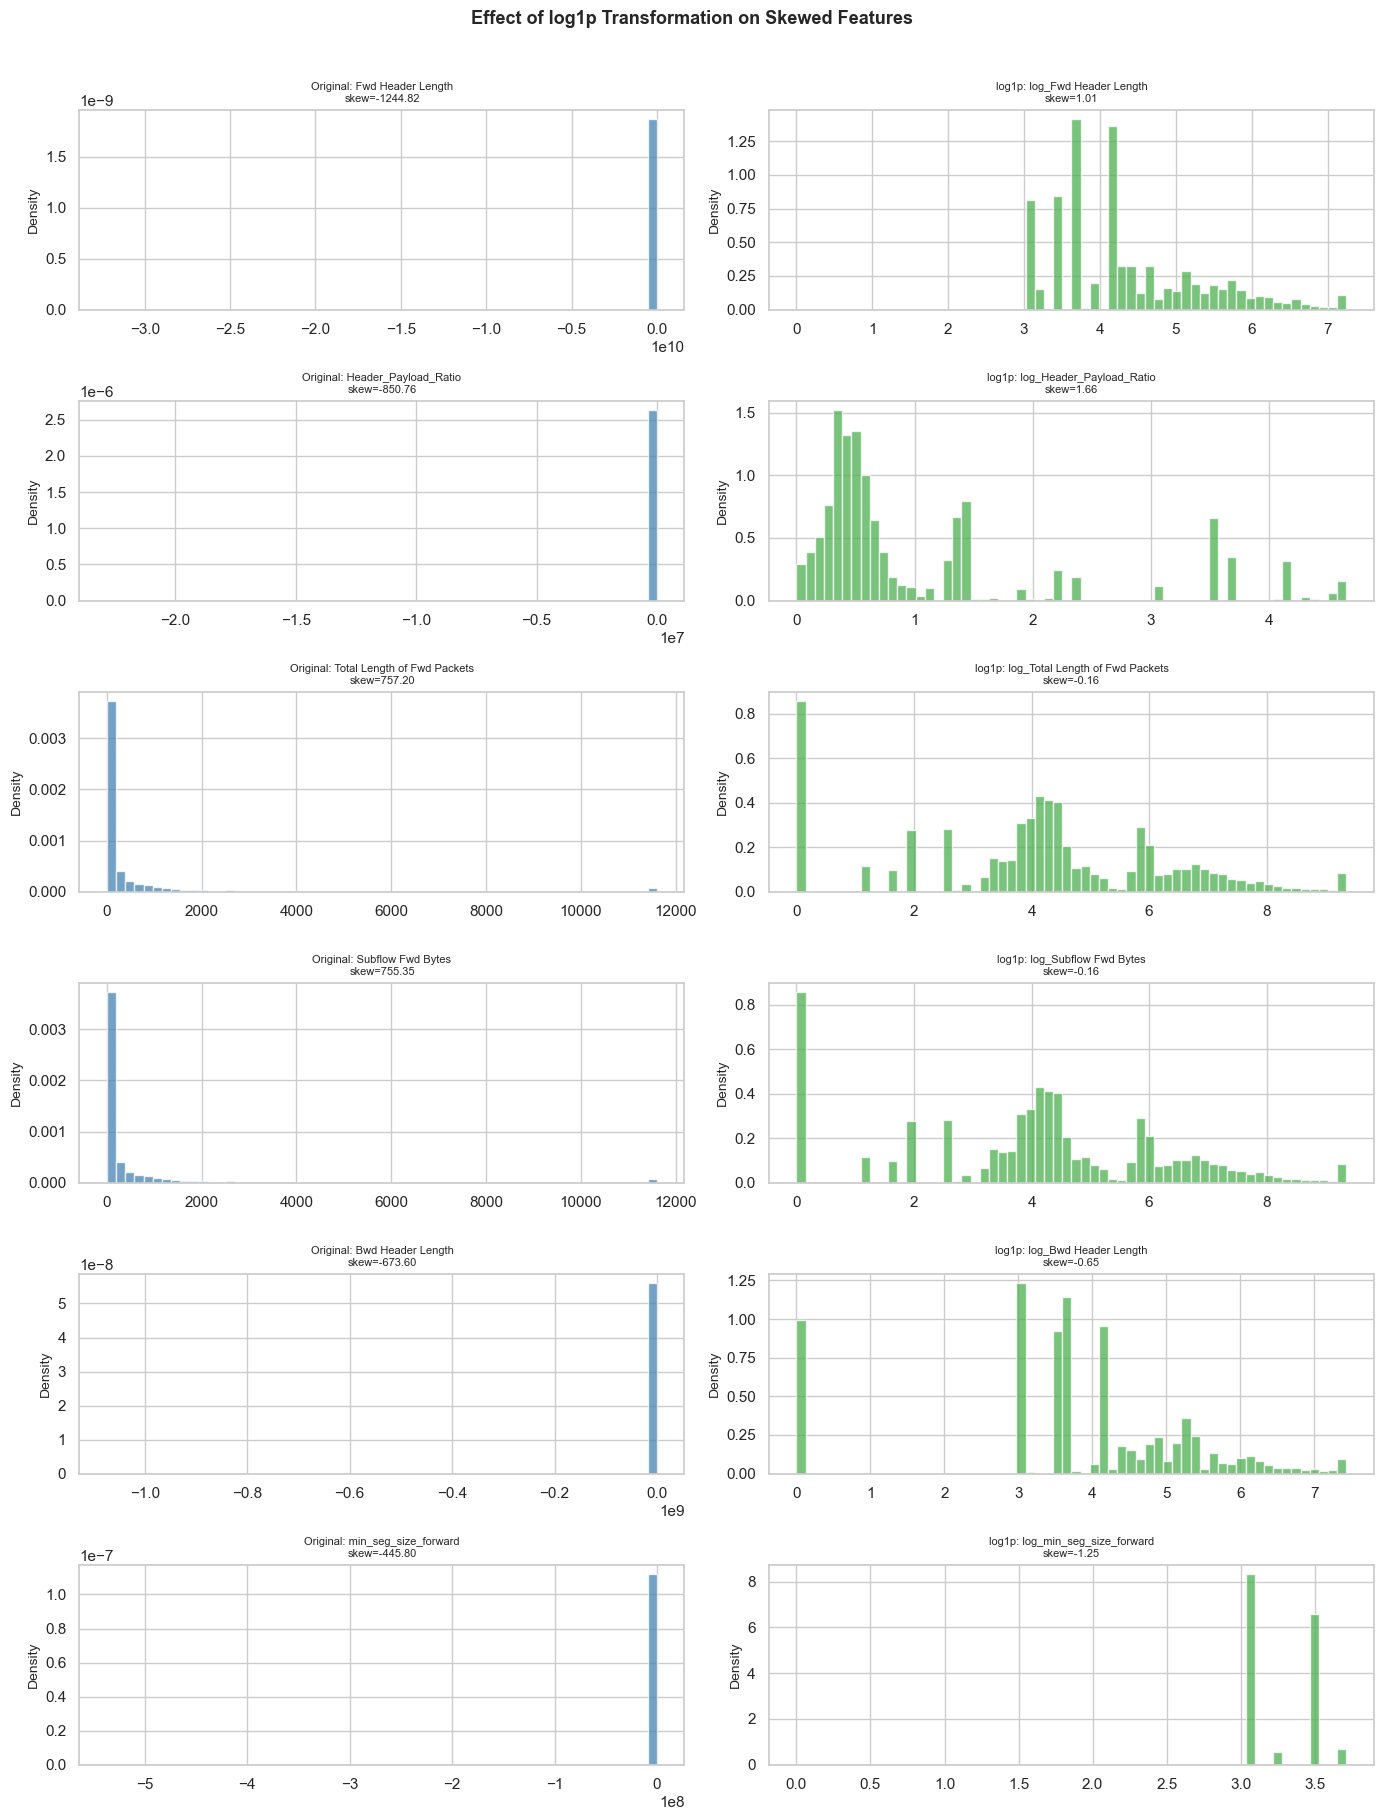

In [15]:
# ── Before vs After skewness comparison (top 6)
compare_pairs = [(c, f'log_{c}') for c in LOG_CANDIDATES[:6]
                 if f'log_{c}' in df.columns]

fig, axes = plt.subplots(len(compare_pairs), 2,
                         figsize=(14, len(compare_pairs)*3))

for i, (orig, logged) in enumerate(compare_pairs):
    for j, (col, color, label) in enumerate([
            (orig,   'steelblue', 'Original'),
            (logged, '#4CAF50',   'log1p')]):
        s = df[col].dropna()
        axes[i][j].hist(s.clip(upper=s.quantile(0.99)), bins=60,
                        color=color, alpha=0.75, edgecolor='white', density=True)
        axes[i][j].set_title(f'{label}: {col}\nskew={s.skew():.2f}', fontsize=8)
        axes[i][j].set_ylabel('Density')

plt.suptitle('Effect of log1p Transformation on Skewed Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


7. Drop Highly Correlated Features

Remove one feature from every pair with **|r| > 0.90** to reduce multicollinearity.
    
We keep the feature with the higher absolute correlation to `Is_Attack`.

In [16]:
# ── Binary label for correlation target
if 'Is_Attack' not in df.columns:
    df['Is_Attack'] = (df['Label'] != 'BENIGN').astype(int)

FEAT_COLS = [c for c in df.select_dtypes(include=np.number).columns
             if c not in ['Is_Attack']]

corr_matrix = df[FEAT_COLS].corr().abs()

# ── Upper triangle pairs
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

THRESHOLD = 0.90
to_drop_corr = set()

# For each pair above threshold, drop the one less correlated with Is_Attack
target_corr = df[FEAT_COLS + ['Is_Attack']].corr()['Is_Attack'].abs()

for col in upper.columns:
    high_corr_partners = upper.index[upper[col] > THRESHOLD].tolist()
    for partner in high_corr_partners:
        if col in to_drop_corr or partner in to_drop_corr:
            continue
        # Keep whichever has higher correlation with target
        corr_col     = target_corr.get(col, 0)
        corr_partner = target_corr.get(partner, 0)
        if corr_col >= corr_partner:
            to_drop_corr.add(partner)
        else:
            to_drop_corr.add(col)

print(f'Features to drop (|r| > {THRESHOLD}): {len(to_drop_corr)}')
for f in sorted(to_drop_corr):
    print(f'  - {f}')

Features to drop (|r| > 0.9): 58
  - Active Mean
  - Avg Bwd Segment Size
  - Bwd IAT Mean
  - Bwd Packet Length Max
  - Bwd Packet Length Mean
  - Down/Up Ratio
  - FIN Flag Count
  - Flow Duration
  - Flow IAT Max
  - Flow IAT Std
  - Flow Packets/s
  - Fwd IAT Max
  - Fwd IAT Mean
  - Fwd PSH Flags
  - Fwd Packet Length Mean
  - Fwd Packet Length Std
  - Fwd URG Flags
  - Has_RST
  - Idle Max
  - Idle Mean
  - Max Packet Length
  - Packet Length Mean
  - Packet Length Std
  - RST Flag Count
  - SYN Flag Count
  - Subflow Bwd Bytes
  - Subflow Fwd Packets
  - Total Backward Packets
  - Total Fwd Packets
  - Total Length of Bwd Packets
  - Total Length of Fwd Packets
  - log_Average Packet Size
  - log_Avg Bwd Segment Size
  - log_Avg Fwd Segment Size
  - log_Bwd Header Length
  - log_Bwd IAT Mean
  - log_Bwd IAT Total
  - log_Bwd Packet Length Max
  - log_Bytes_Per_Packet
  - log_Flow Duration
  - log_Flow IAT Mean
  - log_Flow Packets/s
  - log_Fwd IAT Mean
  - log_Fwd IAT Total
  -

In [17]:
df.drop(columns=[c for c in to_drop_corr if c in df.columns], inplace=True)
print(f'✅ Dropped {len(to_drop_corr)} highly correlated features')
print(f'Shape after correlation drop: {df.shape}') 


✅ Dropped 58 highly correlated features
Shape after correlation drop: (2498243, 72)


In [18]:
# ── Final feature list after all drops
FEATURE_COLS = [c for c in df.select_dtypes(include=np.number).columns
                if c not in ['Is_Attack']]
print(f'Final feature count: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Final feature count: 69
['Fwd Packet Length Max', 'Fwd Packet Length Min', 'Bwd Packet Length Min', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow IAT Mean', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Std', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Packet Length Variance', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Std', 'Active Max', 'Active Min', 'Idle Std', 'Idle Min', 'Fwd_Bwd_Pkt_Ratio', 'Bytes_Per_Packet', 'Header_Payload_Ratio', 'IAT_Fwd_Bwd_Ratio', 'Has_SYN', 'Has_FIN', 'Pkt_Size_Asymmetry', 'Win_Size_Ratio', 'log_Fwd Header Length', 'log_min_seg_size_forward', 'log_act_data_pkt_fwd', 'log_Subflow Bwd Packets'

8. Label Encoding 
We create three label representations for different modelling tasks:
    
- `y_binary` → 0 = Benign, 1 = Attack (binary classification)
               
- `y_multi` → 0–14 integer encoded (multi-class classification)
               
- `label_names` → original string labels

In [19]:
# ── Binary label
df['y_binary'] = (df['Label'] != 'BENIGN').astype(int)
print('Binary label distribution:')
print(df['y_binary'].value_counts())


Binary label distribution:
y_binary
0    2072500
1     425743
Name: count, dtype: int64


In [20]:
# ── Multi-class label (integer encoded)
le = LabelEncoder()
df['y_multi'] = le.fit_transform(df['Label'])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('\nMulti-class label mapping:')
for name, code in sorted(label_mapping.items(), key=lambda x: x[1]):
    code_int  = int(code)
    name_str  = str(name)
    count_int = int((df['Label'] == name).sum())
    print(f'  {code_int:2d} -> {name_str:<40} ({count_int:,} samples)')

joblib.dump(le, 'label_encoder.pkl')
print('\n✅ LabelEncoder saved to label_encoder.pkl')


Multi-class label mapping:
   0 -> BENIGN                                   (2,072,500 samples)
   1 -> Bot                                      (1,948 samples)
   2 -> DDoS                                     (128,016 samples)
   3 -> DoS GoldenEye                            (10,286 samples)
   4 -> DoS Hulk                                 (172,846 samples)
   5 -> DoS Slowhttptest                         (5,228 samples)
   6 -> DoS slowloris                            (5,385 samples)
   7 -> FTP-Patator                              (5,931 samples)
   8 -> Heartbleed                               (11 samples)
   9 -> Infiltration                             (36 samples)
  10 -> PortScan                                 (90,694 samples)
  11 -> SSH-Patator                              (3,219 samples)
  12 -> Web Attack_Brute Force                   (1,470 samples)
  13 -> Web Attack_Sql Injection                 (21 samples)
  14 -> Web Attack_XSS                           (652 samples

9. Train-Test Split (Stratified)

Use stratified split to ensure each attack class is proportionally represented in both train and test sets.
    
We use the multi-class label for stratification.

In [21]:
X = df[FEATURE_COLS].copy()
y_bin   = df['y_binary'].values
y_multi = df['y_multi'].values

X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = \
    train_test_split(
        X, y_bin, y_multi,
        test_size=0.2,
        random_state=42,
        stratify=y_multi       # stratify on multi-class for even coverage
    )

print(f'Training set   : {X_train.shape[0]:,} rows × {X_train.shape[1]} features')
print(f'Test set       : {X_test.shape[0]:,} rows × {X_test.shape[1]} features')


Training set   : 1,998,594 rows × 69 features
Test set       : 499,649 rows × 69 features


In [22]:
# ── Verify class proportions are preserved
train_dist = pd.Series(y_train_multi).value_counts(normalize=True).sort_index()
test_dist  = pd.Series(y_test_multi).value_counts(normalize=True).sort_index()
dist_check = pd.DataFrame({
    'Class'      : le.classes_,
    'Train %'    : (train_dist.values * 100).round(3),
    'Test %'     : (test_dist.values * 100).round(3),
})
print('Class distribution check (train vs test):')
print(dist_check.to_string(index=False))

Class distribution check (train vs test):
                   Class  Train %  Test %
                  BENIGN  82.9580 82.9580
                     Bot   0.0780  0.0780
                    DDoS   5.1240  5.1240
           DoS GoldenEye   0.4120  0.4120
                DoS Hulk   6.9190  6.9190
        DoS Slowhttptest   0.2090  0.2090
           DoS slowloris   0.2160  0.2160
             FTP-Patator   0.2370  0.2370
              Heartbleed   0.0000  0.0000
            Infiltration   0.0010  0.0010
                PortScan   3.6300  3.6300
             SSH-Patator   0.1290  0.1290
  Web Attack_Brute Force   0.0590  0.0590
Web Attack_Sql Injection   0.0010  0.0010
          Web Attack_XSS   0.0260  0.0260


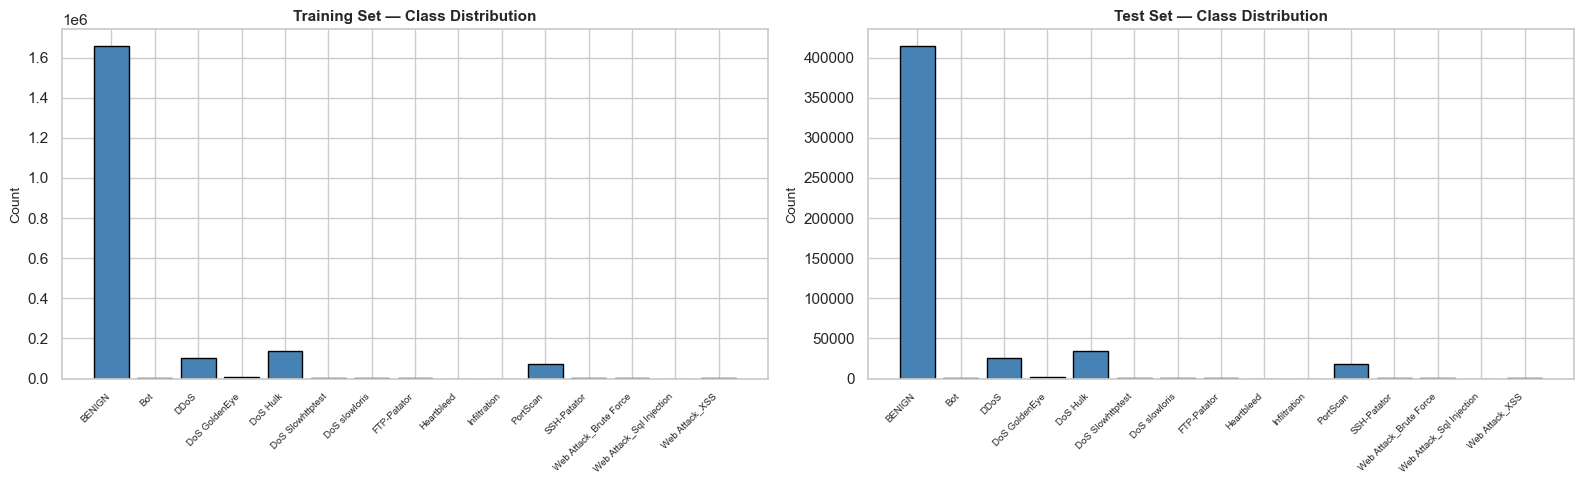

In [23]:
# ── Visualise class split
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, y, title in [(axes[0], y_train_multi, 'Training Set'),
                     (axes[1], y_test_multi,  'Test Set')]:

    counts   = pd.Series(y).value_counts().sort_index()
    x_labels = [str(le.classes_[i]) for i in counts.index]   # ← fix: plain list of str
    x_pos    = np.arange(len(x_labels))                       # ← numeric positions

    ax.bar(x_pos, counts.values, color='steelblue', edgecolor='black')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=7)
    ax.set_title(f'{title} — Class Distribution', fontweight='bold')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


10. Feature Scaling (RobustScaler)

We use RobustScaler (scales using median and IQR) rather than StandardScaler because:

- Network flow features are heavily skewed

- Outliers in this dataset ARE the attacks — StandardScaler would distort them

> ⚠️ **Fit only on training data. Apply to both train and test.

In [24]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform train
X_test_scaled  = scaler.transform(X_test)         # transform test only

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURE_COLS)

print(f'✅ Scaling complete')
print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled shape : {X_test_scaled.shape}')

# Save scaler
joblib.dump(scaler, 'robust_scaler.pkl')
print('✅ Scaler saved to robust_scaler.pkl')


✅ Scaling complete
X_train_scaled shape: (1998594, 69)
X_test_scaled shape : (499649, 69)
✅ Scaler saved to robust_scaler.pkl


In [25]:
# ── Verify scaling: check mean and std of a few features
check_feats = FEATURE_COLS[:5]
scale_check = pd.DataFrame({
    'Feature'       : check_feats,
    'Train Mean'    : X_train_scaled[check_feats].mean().values.round(4),
    'Train Std'     : X_train_scaled[check_feats].std().values.round(4),
    'Test Mean'     : X_test_scaled[check_feats].mean().values.round(4),
    'Test Std'      : X_test_scaled[check_feats].std().values.round(4),
})
print('Scaling check (first 5 features):')
print(scale_check.to_string(index=False))
print('\n💡 Train mean near 0 and std near 1 confirms correct scaling.')


Scaling check (first 5 features):
              Feature  Train Mean  Train Std  Test Mean  Test Std
Fwd Packet Length Max      0.9585     3.7673     0.9671    3.8247
Fwd Packet Length Min      0.4612     1.6467     0.4617    1.6551
Bwd Packet Length Min      0.5230     0.8637     0.5241    0.8690
Bwd Packet Length Std      1.3260     3.0860     1.3271    3.0896
         Flow Bytes/s     14.5935   276.5933    14.5176  274.1158

💡 Train mean near 0 and std near 1 confirms correct scaling.


11. Handle Class Imbalance (RandomOversampling and RandomUndersampling) 

In [26]:
from collections import Counter
print('Class distribution BEFORE RandomOversampling and RandomUndersampling (training set):')
counter_before = Counter(y_train_multi)
for cls_id, cnt in sorted(counter_before.items()):
    name = str(le.classes_[cls_id])   # ← cast numpy.str_ to str
    count = int(cnt)                   # ← cast numpy.int64 to int
    print(f'  {name:<45} : {count:,}')

Class distribution BEFORE RandomOversampling and RandomUndersampling (training set):
  BENIGN                                        : 1,658,000
  Bot                                           : 1,558
  DDoS                                          : 102,413
  DoS GoldenEye                                 : 8,229
  DoS Hulk                                      : 138,277
  DoS Slowhttptest                              : 4,182
  DoS slowloris                                 : 4,308
  FTP-Patator                                   : 4,745
  Heartbleed                                    : 9
  Infiltration                                  : 29
  PortScan                                      : 72,555
  SSH-Patator                                   : 2,575
  Web Attack_Brute Force                        : 1,176
  Web Attack_Sql Injection                      : 17
  Web Attack_XSS                                : 521


In [27]:
from imblearn.over_sampling  import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections             import Counter
# ── Build class ID lookup from actual le.classes_
class_to_id = {str(name): int(idx) 
               for idx, name in enumerate(le.classes_)}

print('Class → ID mapping:')
for name, idx in class_to_id.items():
    print(f'  {idx:2d} : {name}')

Class → ID mapping:
   0 : BENIGN
   1 : Bot
   2 : DDoS
   3 : DoS GoldenEye
   4 : DoS Hulk
   5 : DoS Slowhttptest
   6 : DoS slowloris
   7 : FTP-Patator
   8 : Heartbleed
   9 : Infiltration
  10 : PortScan
  11 : SSH-Patator
  12 : Web Attack_Brute Force
  13 : Web Attack_Sql Injection
  14 : Web Attack_XSS


In [28]:
# ── Step 1: Undersample BENIGN only
# Reduce 1,658,442 → 150,000 (still the largest class but no longer overwhelming)
undersample_strategy = {
    class_to_id['BENIGN']: 150000
}

under = RandomUnderSampler(
    sampling_strategy=undersample_strategy,
    random_state=42
)

X_temp, y_temp = under.fit_resample(X_train_scaled, y_train_multi)

print(f'After undersampling: {X_temp.shape[0]:,} rows')
print(f'BENIGN now         : {Counter(y_temp)[class_to_id["BENIGN"]]:,}')

After undersampling: 490,594 rows
BENIGN now         : 150,000


In [29]:
# ── Step 2: Oversample minorities
# Strategy: bring everything below 5,000 up to 5,000
# (duplicates real rows — no synthetic data, no MemoryError)
counter_temp = Counter(y_temp)
TARGET = 5000   # target minimum per class

oversample_strategy = {
    cls_id: TARGET
    for cls_id, cnt in counter_temp.items()
    if cnt < TARGET
}

print('Oversampling strategy (classes below 5,000):')
for cls_id, target in sorted(oversample_strategy.items()):
    name = str(le.classes_[cls_id])
    current = counter_temp[cls_id]
    print(f'  {name:<40}: {current:,} → {target:,}')

Oversampling strategy (classes below 5,000):
  Bot                                     : 1,558 → 5,000
  DoS Slowhttptest                        : 4,182 → 5,000
  DoS slowloris                           : 4,308 → 5,000
  FTP-Patator                             : 4,745 → 5,000
  Heartbleed                              : 9 → 5,000
  Infiltration                            : 29 → 5,000
  SSH-Patator                             : 2,575 → 5,000
  Web Attack_Brute Force                  : 1,176 → 5,000
  Web Attack_Sql Injection                : 17 → 5,000
  Web Attack_XSS                          : 521 → 5,000


In [30]:
over = RandomOverSampler(
    sampling_strategy=oversample_strategy,
    random_state=42
)

X_resampled, y_resampled = over.fit_resample(X_temp, y_temp)

print(f'\nBefore resampling : {X_train_scaled.shape[0]:,} rows')
print(f'After  resampling : {X_resampled.shape[0]:,} rows')
print(f'Memory reduced by : {(1 - X_resampled.shape[0]/X_train_scaled.shape[0])*100:.1f}%')


Before resampling : 1,998,594 rows
After  resampling : 521,474 rows
Memory reduced by : 73.9%


In [31]:
# ── Step 3: Verify final distribution
print('\nFinal class distribution:')
counter_final = Counter(y_resampled)
for cls_id, cnt in sorted(counter_final.items()):
    name    = str(le.classes_[cls_id])
    before  = counter_before.get(cls_id, 0)
    change  = '↓' if cnt < before else ('↑' if cnt > before else '=')
    print(f'  {name:<40}: {cnt:,}  {change}  (was {before:,})')
print(f'\nTotal: {sum(counter_final.values()):,} rows')


Final class distribution:
  BENIGN                                  : 150,000  ↓  (was 1,658,000)
  Bot                                     : 5,000  ↑  (was 1,558)
  DDoS                                    : 102,413  =  (was 102,413)
  DoS GoldenEye                           : 8,229  =  (was 8,229)
  DoS Hulk                                : 138,277  =  (was 138,277)
  DoS Slowhttptest                        : 5,000  ↑  (was 4,182)
  DoS slowloris                           : 5,000  ↑  (was 4,308)
  FTP-Patator                             : 5,000  ↑  (was 4,745)
  Heartbleed                              : 5,000  ↑  (was 9)
  Infiltration                            : 5,000  ↑  (was 29)
  PortScan                                : 72,555  =  (was 72,555)
  SSH-Patator                             : 5,000  ↑  (was 2,575)
  Web Attack_Brute Force                  : 5,000  ↑  (was 1,176)
  Web Attack_Sql Injection                : 5,000  ↑  (was 17)
  Web Attack_XSS                          :

In [32]:
# ── Step 4: Train classifier on resampled data
from sklearn.ensemble import RandomForestClassifier
import joblib

clf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    max_samples=0.8,
    verbose=1
)

print('Training Random Forest...')
clf.fit(X_resampled, y_resampled)
print('✅ Training complete')

# Evaluate on original unmodified test set
test_acc = clf.score(X_test_scaled, y_test_multi)
print(f'\nTest Accuracy: {test_acc*100:.2f}%')

# Save
joblib.dump(clf,    'cicids2017_rf_model.pkl')
joblib.dump(scaler, 'cicids2017_scaler.pkl')
joblib.dump(le,     'cicids2017_label_encoder.pkl')
print('✅ All artifacts saved')

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   16.5s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   42.8s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


✅ Training complete


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.7s



Test Accuracy: 99.83%
✅ All artifacts saved


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    2.2s finished


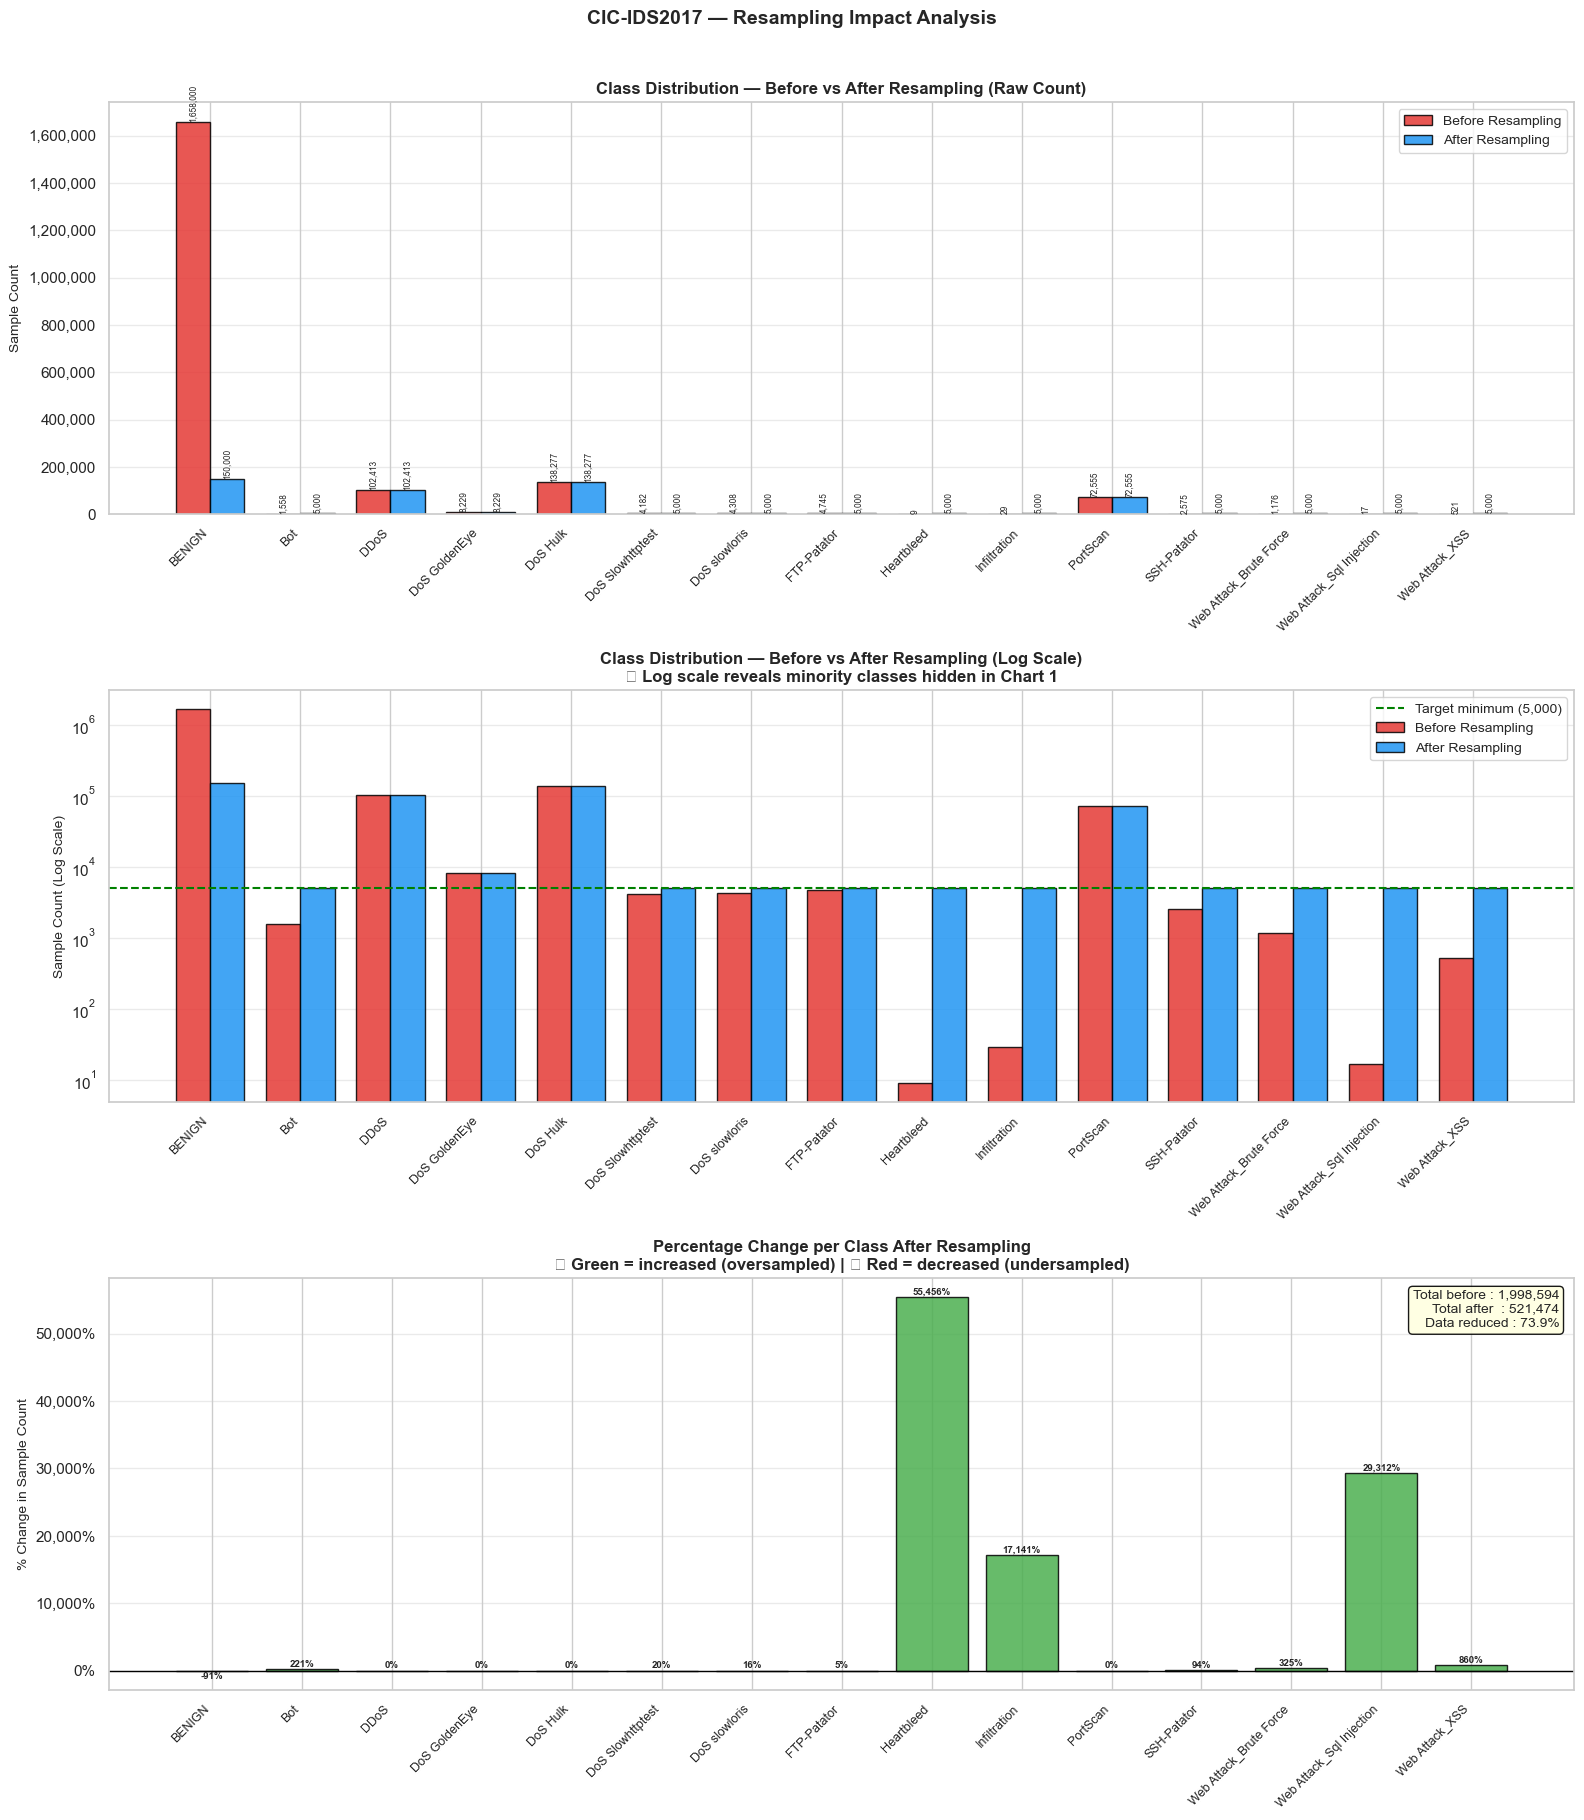

✅ Chart saved to resampling_comparison.png


In [33]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# ── Build data for both distributions
labels_ids = sorted(set(list(counter_before.keys()) + list(counter_final.keys())))
class_names = [str(le.classes_[i]) for i in labels_ids]

before_counts = [counter_before.get(i, 0) for i in labels_ids]
after_counts  = [counter_final.get(i,  0) for i in labels_ids]

x = np.arange(len(class_names))
width = 0.38

# ── Plot
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

# ── Chart 1: Grouped bar — Before vs After
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, before_counts, width,
                label='Before Resampling', color='#E53935', alpha=0.85, edgecolor='black')
bars2 = ax1.bar(x + width/2, after_counts,  width,
                label='After Resampling',  color='#2196F3', alpha=0.85, edgecolor='black')

ax1.set_xticks(x)
ax1.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Sample Count')
ax1.set_title('Class Distribution — Before vs After Resampling (Raw Count)',
              fontweight='bold', fontsize=12)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.4)

# Annotate bars
for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, h,
                 f'{int(h):,}', ha='center', va='bottom', fontsize=6, rotation=90)
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, h,
                 f'{int(h):,}', ha='center', va='bottom', fontsize=6, rotation=90)

# ── Chart 2: Log scale — shows minorities clearly
ax2 = axes[1]
ax2.bar(x - width/2, before_counts, width,
        label='Before Resampling', color='#E53935', alpha=0.85, edgecolor='black')
ax2.bar(x + width/2, after_counts,  width,
        label='After Resampling',  color='#2196F3', alpha=0.85, edgecolor='black')

ax2.set_xticks(x)
ax2.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
ax2.set_yscale('log')
ax2.set_ylabel('Sample Count (Log Scale)')
ax2.set_title('Class Distribution — Before vs After Resampling (Log Scale)\n'
              '★ Log scale reveals minority classes hidden in Chart 1',
              fontweight='bold', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.4)
ax2.axhline(y=5000, color='green', linestyle='--',
            linewidth=1.5, label='Target minimum (5,000)')
ax2.legend(fontsize=10)

# ── Chart 3: Percentage change per class
pct_change = []
for b, a in zip(before_counts, after_counts):
    if b == 0:
        pct_change.append(0)
    else:
        pct_change.append(((a - b) / b) * 100)

colors_pct = ['#4CAF50' if p >= 0 else '#E53935' for p in pct_change]
ax3 = axes[2]
bars3 = ax3.bar(x, pct_change, color=colors_pct,
                edgecolor='black', alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
ax3.axhline(y=0, color='black', linewidth=1)
ax3.set_ylabel('% Change in Sample Count')
ax3.set_title('Percentage Change per Class After Resampling\n'
              '🟢 Green = increased (oversampled) | 🔴 Red = decreased (undersampled)',
              fontweight='bold', fontsize=12)
ax3.grid(axis='y', alpha=0.4)
ax3.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'{v:,.0f}%'))

# Annotate % values
for bar, pct in zip(bars3, pct_change):
    va  = 'bottom' if pct >= 0 else 'top'
    off = 50 if pct >= 0 else -50
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + off,
             f'{pct:,.0f}%', ha='center', va=va, fontsize=7, fontweight='bold')

# ── Summary text box
total_before = sum(before_counts)
total_after  = sum(after_counts)
reduction    = (1 - total_after / total_before) * 100
summary_txt  = (f'Total before : {total_before:,}\n'
                f'Total after  : {total_after:,}\n'
                f'Data reduced : {reduction:.1f}%')
ax3.text(0.99, 0.97, summary_txt,
         transform=ax3.transAxes,
         fontsize=10, verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightyellow',
                   edgecolor='black', alpha=0.9))

plt.suptitle('CIC-IDS2017 — Resampling Impact Analysis',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('resampling_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Chart saved to resampling_comparison.png')

Save Preprocessed Data

Save the cleaned, engineered, and scaled arrays so you don't need to re-run this notebook for modelling.

In [34]:
import os
OUT_DIR = 'preprocessed'
os.makedirs(OUT_DIR, exist_ok=True)
import numpy as np
# ── Save as numpy arrays (fast to load)
np.save(f'{OUT_DIR}/X_train.npy',            X_train.values)
np.save(f'{OUT_DIR}/X_test.npy',             X_test.values)
np.save(f'{OUT_DIR}/X_train_scaled.npy',     X_train_scaled.values)
np.save(f'{OUT_DIR}/X_test_scaled.npy',      X_test_scaled.values)
np.save(f'{OUT_DIR}/X_train_resampled.npy', X_temp)
np.save(f'{OUT_DIR}/y_train_multi.npy',      y_train_multi)
np.save(f'{OUT_DIR}/y_test_multi.npy',       y_test_multi)
np.save(f'{OUT_DIR}/y_train_binary.npy',     y_train_bin)
np.save(f'{OUT_DIR}/y_test_binary.npy',      y_test_bin)
np.save(f'{OUT_DIR}/y_train_multi_res.npy',  y_temp)

# ── Save feature names
pd.Series(FEATURE_COLS).to_csv(f'{OUT_DIR}/feature_names.csv', index=False)

# ── Save artifacts
joblib.dump(le,     f'{OUT_DIR}/label_encoder.pkl')
joblib.dump(scaler, f'{OUT_DIR}/robust_scaler.pkl')

print('✅ All preprocessed arrays saved to /preprocessed/')
print(f'   X_train_resampled shape : {X_temp.shape}')
print(f'   X_test_scaled shape     : {X_test_scaled.shape}')
for f in os.listdir(OUT_DIR):
    size = os.path.getsize(f'{OUT_DIR}/{f}') / 1024
    print(f'   {f:<40} {size:,.1f} KB')


✅ All preprocessed arrays saved to /preprocessed/
   X_train_resampled shape : (490594, 69)
   X_test_scaled shape     : (499649, 69)
   .ipynb_checkpoints                       0.0 KB
   feature_names.csv                        1.3 KB
   label_encoder.pkl                        0.7 KB
   robust_scaler.pkl                        3.1 KB
   X_test.npy                               269,342.2 KB
   X_test_scaled.npy                        269,342.2 KB
   X_train.npy                              1,077,367.2 KB
   X_train_resampled.npy                    264,461.0 KB
   X_train_scaled.npy                       1,077,367.2 KB
   y_test_binary.npy                        3,903.6 KB
   y_test_multi.npy                         3,903.6 KB
   y_train_binary.npy                       15,614.1 KB
   y_train_multi.npy                        15,614.1 KB
   y_train_multi_res.npy                    3,832.9 KB


================================================ MODEL TRAINING==================================================

In [35]:
from sklearn.ensemble        import RandomForestClassifier
from sklearn.tree            import DecisionTreeClassifier 
from sklearn.metrics         import (accuracy_score, f1_score,
                                     precision_score, recall_score,
                                     classification_report,
                                     confusion_matrix, roc_auc_score,
                                     RocCurveDisplay)
from sklearn.preprocessing   import label_binarize
from xgboost                 import XGBClassifier
from lightgbm                import LGBMClassifier
from catboost                import CatBoostClassifier

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')
plt.rcParams.update({'axes.titlesize':11,'axes.labelsize':10,
                     'xtick.labelsize':8, 'ytick.labelsize':8})
print('✅ All libraries loaded')


✅ All libraries loaded


In [36]:
CLASS_NAMES = [str(c) for c in le.classes_]
N_CLASSES   = len(CLASS_NAMES)

print(f'Training samples : {X_resampled.shape[0]:,}')
print(f'Test samples     : {X_test_scaled.shape[0]:,}')
print(f'Features         : {X_resampled.shape[1]}')
print(f'Classes          : {N_CLASSES}')
print(f'Class names      : {CLASS_NAMES}')

Training samples : 521,474
Test samples     : 499,649
Features         : 69
Classes          : 15
Class names      : ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack_Brute Force', 'Web Attack_Sql Injection', 'Web Attack_XSS']


2. Model Definitions 
Six models — from simple baseline to state-of-the-art boosting

In [37]:
MODELS = {

    'Decision Tree': DecisionTreeClassifier(
        max_depth=20,
        class_weight='balanced',
        random_state=42
    ),

    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        max_samples=0.8,
        n_jobs=-1,
        random_state=42,
        verbose=0
    ),

    'XGBoost': XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        use_label_encoder=False,
        eval_metric='mlogloss',
        n_jobs=-1,
        random_state=42,
        verbosity=0
    ),

    'LightGBM': LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42,
        verbose=-1            # suppress LightGBM output
    ),

    'CatBoost': CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=6,
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0             # suppress CatBoost output
    ),
}

print(f'✅ {len(MODELS)} models defined:')
for name in MODELS:
    print(f'   • {name}')


✅ 5 models defined:
   • Decision Tree
   • Random Forest
   • XGBoost
   • LightGBM
   • CatBoost


3. Train All Models 

Each model is trained on `X_resampled` / `y_resampled` and evaluated on the original unmodified test set.

In [38]:
import warnings, time, joblib
warnings.filterwarnings('ignore')
results    = {}   # stores metrics for every model
trained    = {}   # stores fitted model objects
train_times = {}

for name, model in MODELS.items():
    print(f'\n{'='*55}')
    print(f'  Training: {name}')
    print(f'{'='*55}')

    start = time.time()
    model.fit(X_resampled, y_resampled)
    elapsed = time.time() - start
    train_times[name] = round(elapsed, 2)

    # ── Predictions
    y_pred  = model.predict(X_test_scaled)
    y_prob  = None
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_scaled)

    # ── Metrics
    acc  = accuracy_score(y_test_multi, y_pred)
    f1_w = f1_score(y_test_multi, y_pred, average='weighted', zero_division=0)
    f1_m = f1_score(y_test_multi, y_pred, average='macro',    zero_division=0)
    prec = precision_score(y_test_multi, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test_multi, y_pred, average='weighted',    zero_division=0)

    # ROC-AUC (macro OvR)
    try:
        auc = roc_auc_score(
            y_test_multi, y_prob,
            multi_class='ovr', average='macro'
        ) if y_prob is not None else None
    except Exception:
        auc = None

    results[name] = {
        'Accuracy'          : round(acc  * 100, 3),
        'Weighted F1'       : round(f1_w * 100, 3),
        'Macro F1'          : round(f1_m * 100, 3),
        'Weighted Precision': round(prec * 100, 3),
        'Weighted Recall'   : round(rec  * 100, 3),
        'ROC-AUC (macro)'   : round(auc  * 100, 3) if auc else 'N/A',
        'Train Time (s)'    : elapsed,
        'y_pred'            : y_pred,
        'y_prob'            : y_prob,
    }
    trained[name] = model

    print(f'  ✅ Done in {elapsed:.1f}s')
    print(f'  Accuracy     : {acc*100:.3f}%')
    print(f'  Weighted F1  : {f1_w*100:.3f}%')
    print(f'  Macro F1     : {f1_m*100:.3f}%')
    print(f'  ROC-AUC      : {auc*100:.3f}%' if auc else '  ROC-AUC: N/A')

print('\n✅ All models trained')



  Training: Decision Tree
  ✅ Done in 26.9s
  Accuracy     : 99.713%
  Weighted F1  : 99.730%
  Macro F1     : 77.306%
  ROC-AUC      : 92.136%

  Training: Random Forest
  ✅ Done in 42.6s
  Accuracy     : 99.826%
  Weighted F1  : 99.830%
  Macro F1     : 87.201%
  ROC-AUC      : 99.300%

  Training: XGBoost
  ✅ Done in 161.5s
  Accuracy     : 99.818%
  Weighted F1  : 99.828%
  Macro F1     : 87.807%
  ROC-AUC      : 99.962%

  Training: LightGBM
  ✅ Done in 99.6s
  Accuracy     : 0.775%
  Weighted F1  : 1.051%
  Macro F1     : 0.483%
  ROC-AUC      : 50.704%

  Training: CatBoost
  ✅ Done in 538.1s
  Accuracy     : 97.901%
  Weighted F1  : 98.488%
  Macro F1     : 61.666%
  ROC-AUC      : 99.863%

✅ All models trained


4. Classification Reports

Per-class Precision, Recall and F1 for every model — the most important evaluation for imbalanced datasets.

In [39]:
for name in MODELS:
    print(f'\n{"-"*65}')
    print(f'  {name} — Classification Report')
    print(f'{"-"*65}')
    print(classification_report(
        y_test_multi,
        results[name]['y_pred'],
        target_names=CLASS_NAMES,
        zero_division=0
    ))



-----------------------------------------------------------------
  Decision Tree — Classification Report
-----------------------------------------------------------------
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    414500
                     Bot       0.64      0.96      0.77       390
                    DDoS       1.00      1.00      1.00     25603
           DoS GoldenEye       0.95      1.00      0.97      2057
                DoS Hulk       0.99      1.00      1.00     34569
        DoS Slowhttptest       0.90      0.99      0.94      1046
           DoS slowloris       0.89      0.99      0.94      1077
             FTP-Patator       0.98      1.00      0.99      1186
              Heartbleed       0.50      0.50      0.50         2
            Infiltration       0.38      0.86      0.52         7
                PortScan       0.99      1.00      0.99     18139
             SSH-Patator       0.9

5. Confusion Matrices

Normalised confusion matrices (row = true label, col = predicted label).
    
Values show **recall per class** — what % of each attack type was correctly identified.

In [40]:
def plot_confusion_matrix(y_true, y_pred, class_names, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f',
        cmap='Blues', ax=ax,
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.3,
        annot_kws={'size': 6},
        vmin=0, vmax=1,
        cbar_kws={'shrink': 0.7}
    )
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True',      fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    ax.tick_params(axis='y', rotation=0,  labelsize=6)

print('✅ Function defined')

✅ Function defined


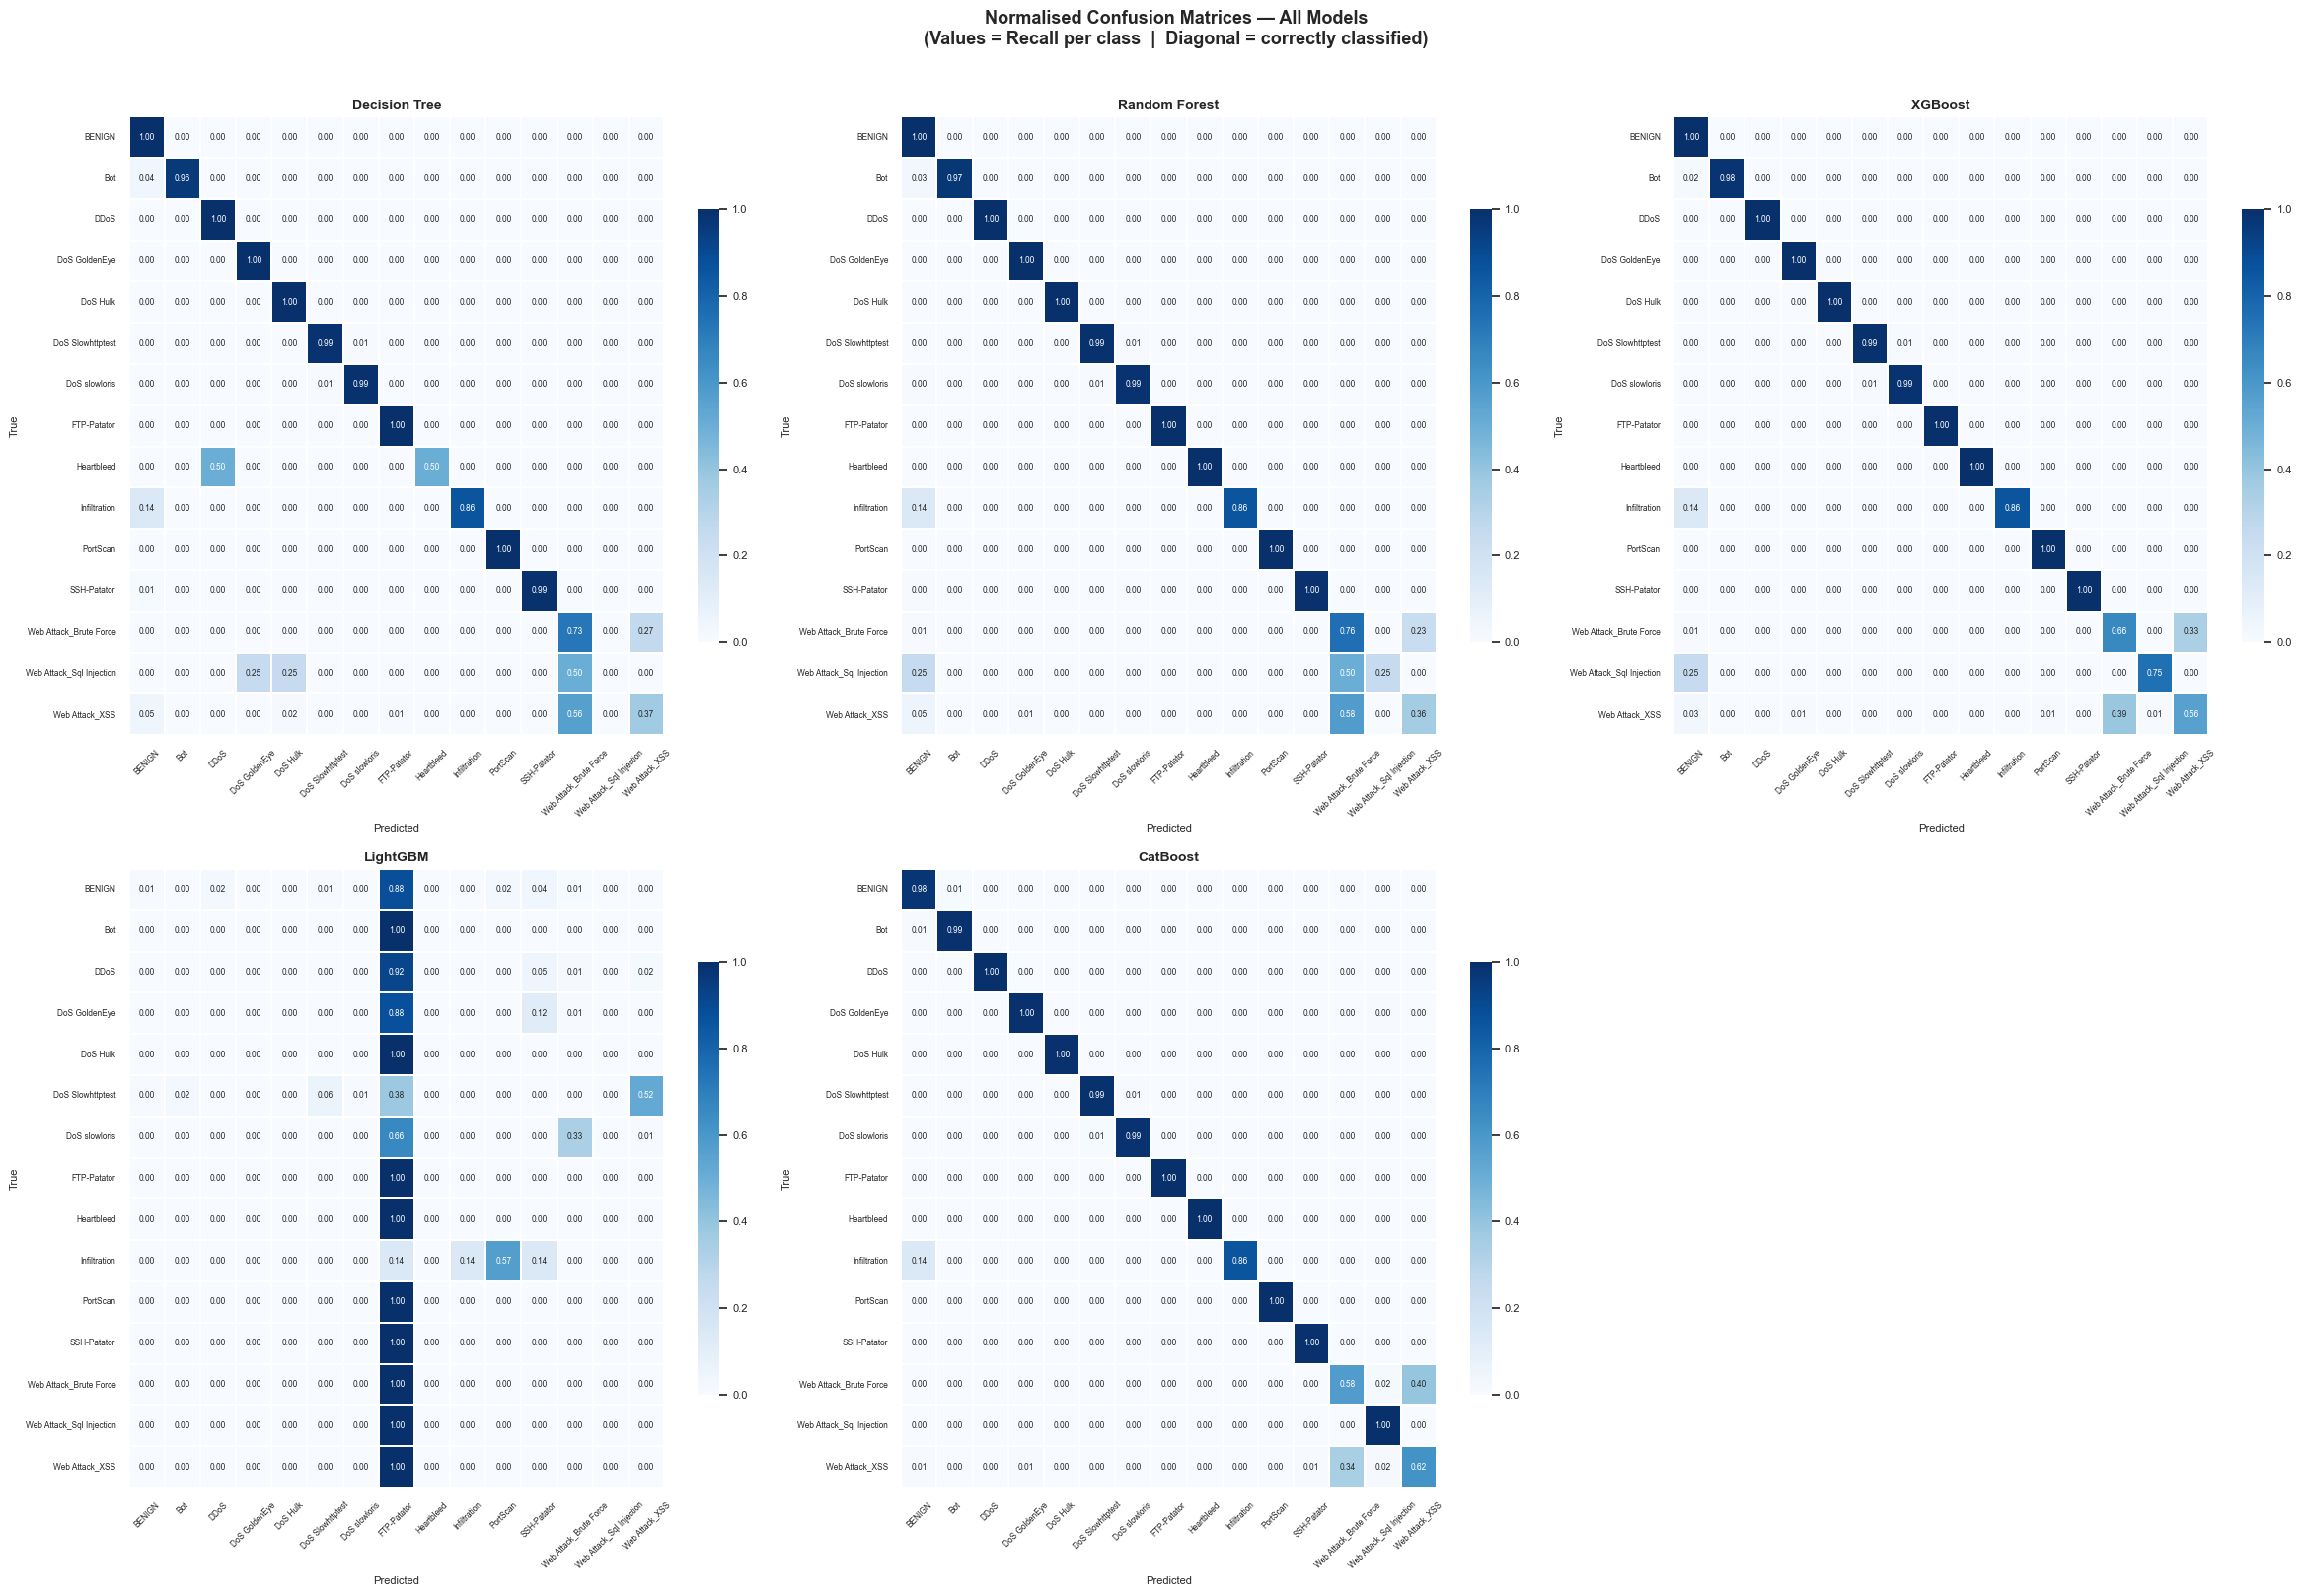

In [41]:
import math

valid_models = [name for name in MODELS if name in results]
n_models     = len(valid_models)
n_cols       = 3
n_rows       = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 8, n_rows * 8))
axes      = axes.flatten()

for i, name in enumerate(valid_models):
    plot_confusion_matrix(
        y_test_multi,
        results[name]['y_pred'],
        CLASS_NAMES, name, axes[i]
    )

# ── This hides the empty 6th slot
for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Normalised Confusion Matrices — All Models\n'
    '(Values = Recall per class  |  Diagonal = correctly classified)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

6. ROC Curves

One-vs-Rest ROC curves for each model. Higher AUC = better discrimination between each attack class and all others.

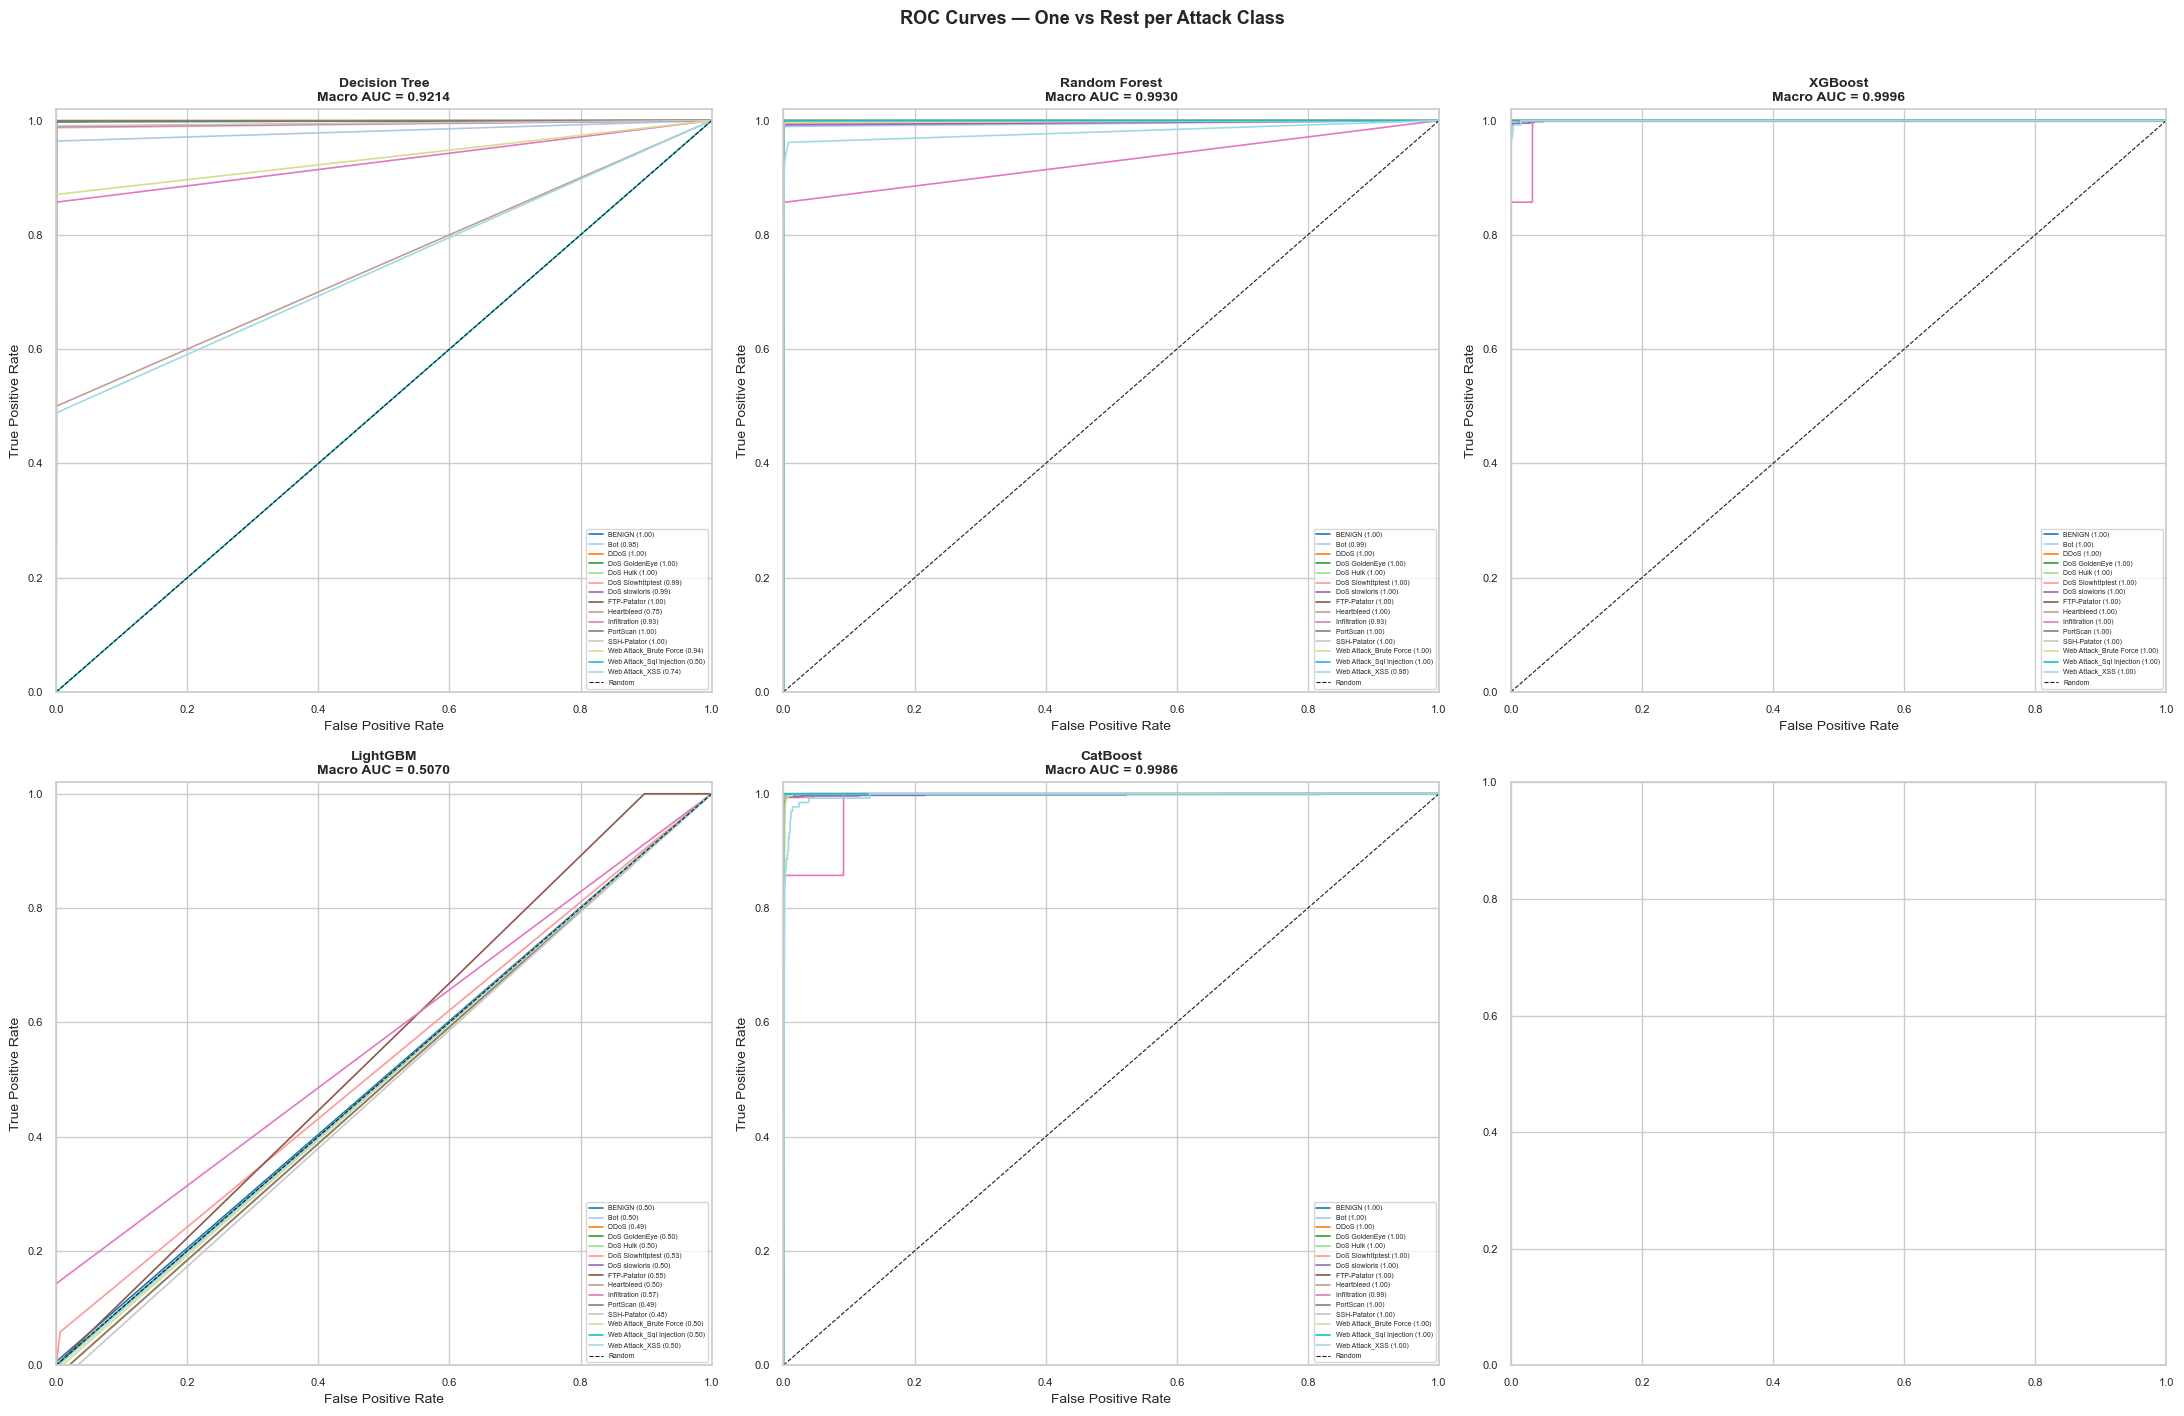

✅ Saved to roc_curves.png


In [42]:
# ── Binarise test labels for OvR ROC
y_test_bin_matrix = label_binarize(y_test_multi,
                                    classes=list(range(N_CLASSES)))

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes = axes.flatten()

for i, name in enumerate(MODELS):
    y_prob = results[name]['y_prob']
    ax     = axes[i]

    if y_prob is None:
        ax.text(0.5, 0.5, 'predict_proba\nnot available',
                ha='center', va='center', fontsize=12)
        ax.set_title(name, fontweight='bold')
        continue

    # Plot one ROC curve per class
    colors = plt.cm.tab20(np.linspace(0, 1, N_CLASSES))
    aucs   = []
    for j, cls_name in enumerate(CLASS_NAMES):
        if y_test_bin_matrix[:, j].sum() == 0:
            continue
        try:
            auc = roc_auc_score(y_test_bin_matrix[:, j], y_prob[:, j])
            from sklearn.metrics import roc_curve
            fpr, tpr, _ = roc_curve(y_test_bin_matrix[:, j], y_prob[:, j])
            ax.plot(fpr, tpr, color=colors[j], lw=1.2,
                    label=f'{cls_name} ({auc:.2f})')
            aucs.append(auc)
        except Exception:
            pass

    ax.plot([0,1],[0,1],'k--', lw=0.8, label='Random')
    mean_auc = np.mean(aucs) if aucs else 0
    ax.set_title(f'{name}\nMacro AUC = {mean_auc:.4f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=5, ncol=1)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle('ROC Curves — One vs Rest per Attack Class',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved to roc_curves.png')


7. Model Comparison Dashboard

Side-by-side comparison of all 5 models across every metric.

In [43]:
# ── Build comparison table
metrics = ['Accuracy','Weighted F1','Macro F1',
           'Weighted Precision','Weighted Recall','ROC-AUC (macro)']

compare_df = pd.DataFrame({
    name: {m: results[name][m] for m in metrics}
    for name in MODELS
}).T

# Add train time
compare_df['Train Time (s)'] = [
    round(results[name]['Train Time (s)'], 1) for name in MODELS
]

# Highlight best value per metric
print('='*75)
print('          MODEL COMPARISON TABLE')
print('='*75)
print(compare_df.to_string())
print('\n★ Best value per metric:')
for m in metrics:
    valid = compare_df[m][compare_df[m] != 'N/A']
    if len(valid) > 0:
        best_model = valid.astype(float).idxmax()
        best_val   = valid.astype(float).max()
        print(f'  {m:<25}: {best_model:<22} ({best_val:.3f}%)')

          MODEL COMPARISON TABLE
               Accuracy  Weighted F1  Macro F1  Weighted Precision  Weighted Recall  ROC-AUC (macro)  Train Time (s)
Decision Tree   99.7130      99.7300   77.3060             99.7560          99.7130          92.1360         26.9000
Random Forest   99.8260      99.8300   87.2010             99.8390          99.8260          99.3000         42.6000
XGBoost         99.8180      99.8280   87.8070             99.8470          99.8180          99.9620        161.5000
LightGBM         0.7750       1.0510    0.4830             82.8050           0.7750          50.7040         99.6000
CatBoost        97.9010      98.4880   61.6660             99.2270          97.9010          99.8630        538.1000

★ Best value per metric:
  Accuracy                 : Random Forest          (99.826%)
  Weighted F1              : Random Forest          (99.830%)
  Macro F1                 : XGBoost                (87.807%)
  Weighted Precision       : XGBoost                (

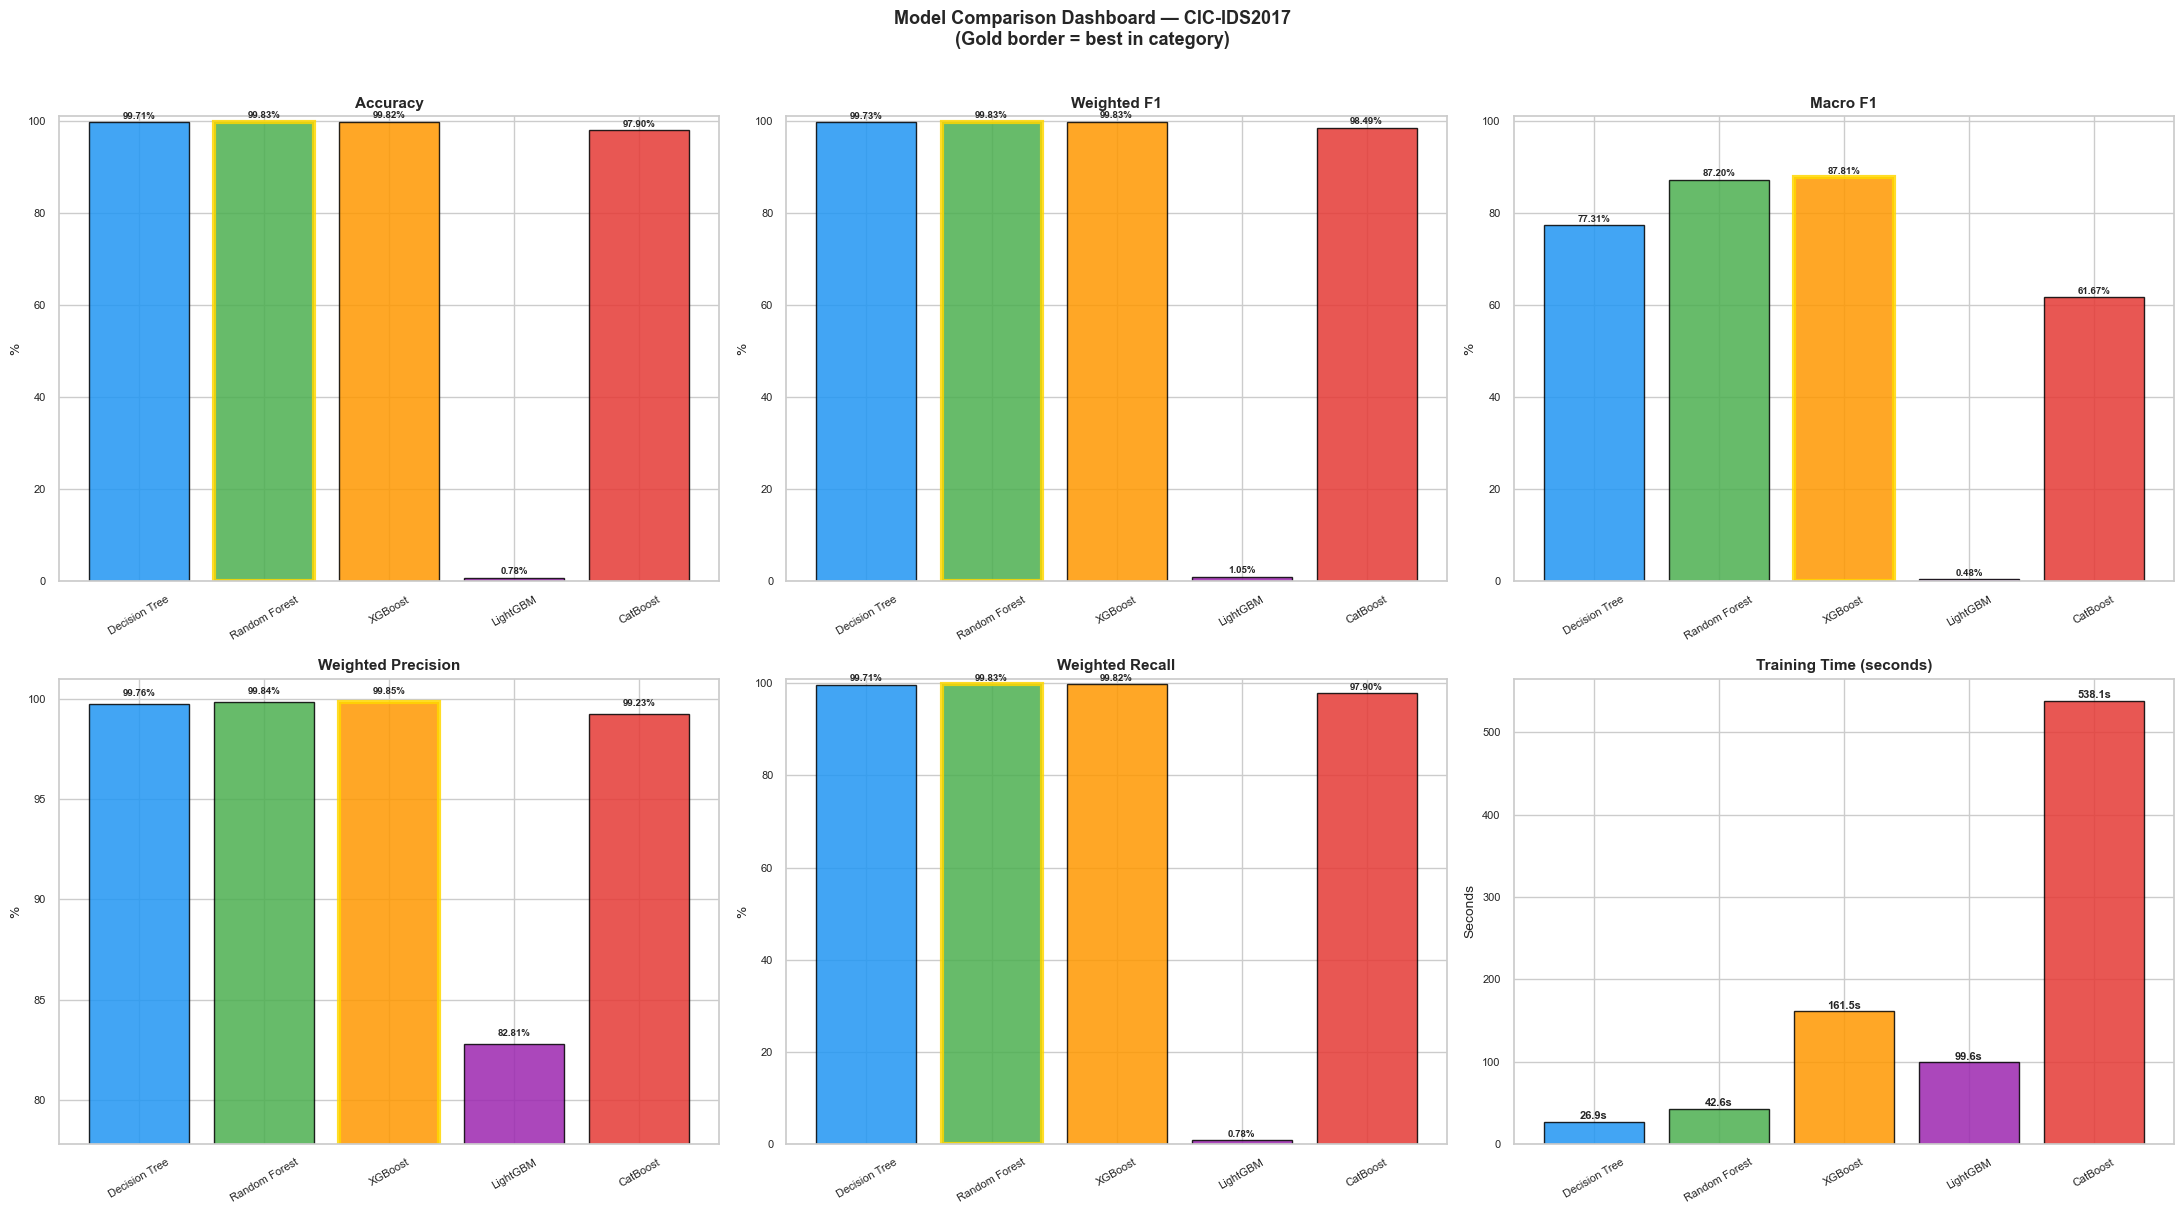

✅ Saved to model_comparison.png


In [44]:
# ── Bar chart comparison across all metrics
numeric_metrics = ['Accuracy','Weighted F1','Macro F1',
                   'Weighted Precision','Weighted Recall']

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()
model_names  = list(MODELS.keys())
bar_colors   = ['#2196F3','#4CAF50','#FF9800',
                '#9C27B0','#E53935','#009688']

for i, metric in enumerate(numeric_metrics):
    vals = [float(results[m][metric])
            if results[m][metric] != 'N/A' else 0
            for m in model_names]

    bars = axes[i].bar(model_names, vals,
                       color=bar_colors, edgecolor='black', alpha=0.85)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_ylabel('%')
    axes[i].set_ylim([max(0, min(vals)-5), 101])
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)

    for bar, val in zip(bars, vals):
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.2f}%',
            ha='center', va='bottom', fontsize=7, fontweight='bold'
        )

    # Highlight best bar
    best_idx = int(np.argmax(vals))
    axes[i].patches[best_idx].set_edgecolor('gold')
    axes[i].patches[best_idx].set_linewidth(3)

# ── Training time chart
times = [results[m]['Train Time (s)'] for m in model_names]
axes[5].bar(model_names, times, color=bar_colors,
            edgecolor='black', alpha=0.85)
axes[5].set_title('Training Time (seconds)', fontweight='bold')
axes[5].set_ylabel('Seconds')
axes[5].tick_params(axis='x', rotation=30, labelsize=8)
for bar, t in zip(axes[5].patches, times):
    axes[5].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{t:.1f}s',
        ha='center', va='bottom', fontsize=8, fontweight='bold'
    )

plt.suptitle('Model Comparison Dashboard — CIC-IDS2017\n'
             '(Gold border = best in category)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved to model_comparison.png')


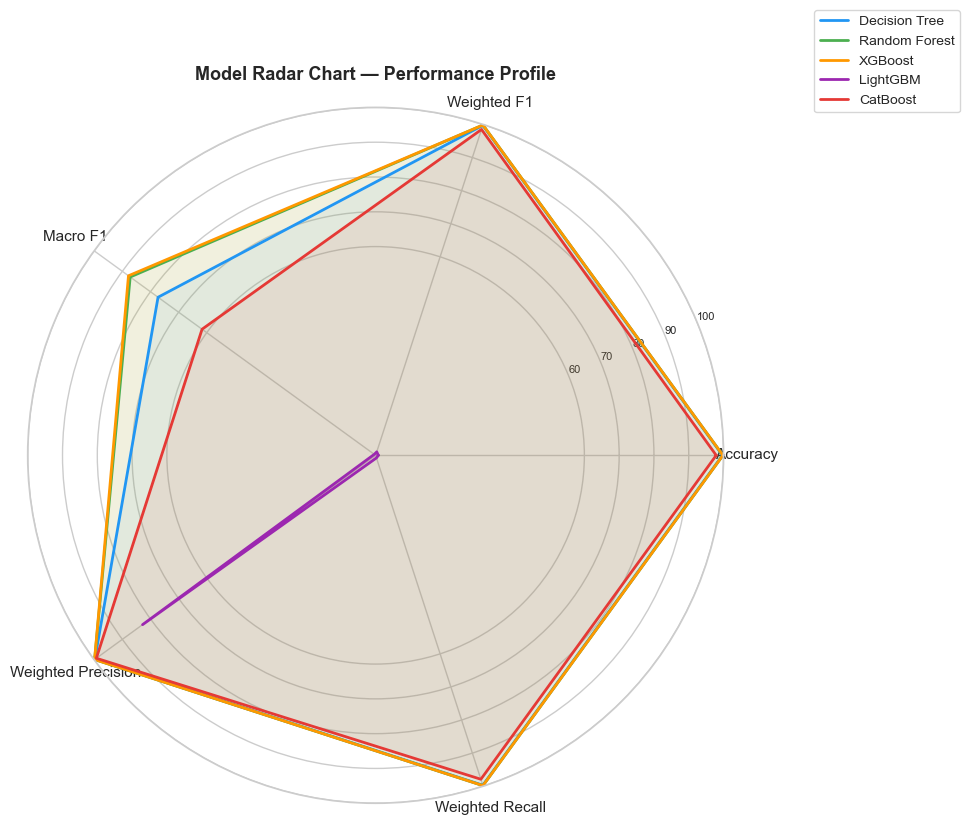

✅ Saved to model_radar.png


In [45]:
# ── Radar chart — overall model profile
from matplotlib.patches import FancyArrowPatch
import matplotlib.cm as cm

radar_metrics = ['Accuracy','Weighted F1','Macro F1',
                 'Weighted Precision','Weighted Recall']
N = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(10, 10),
                        subplot_kw=dict(polar=True))

for idx, (name, color) in enumerate(zip(model_names, bar_colors)):
    vals_r = [float(results[name][m]) for m in radar_metrics]
    vals_r += vals_r[:1]
    ax.plot(angles, vals_r, color=color, linewidth=2,
            linestyle='solid', label=name)
    ax.fill(angles, vals_r, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_ylim(0, 100)
ax.set_yticks([60, 70, 80, 90, 100])
ax.set_yticklabels(['60','70','80','90','100'], fontsize=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.set_title('Model Radar Chart — Performance Profile',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('model_radar.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved to model_radar.png')


8. Feature Importance

Top 20 most important features for each tree-based model.

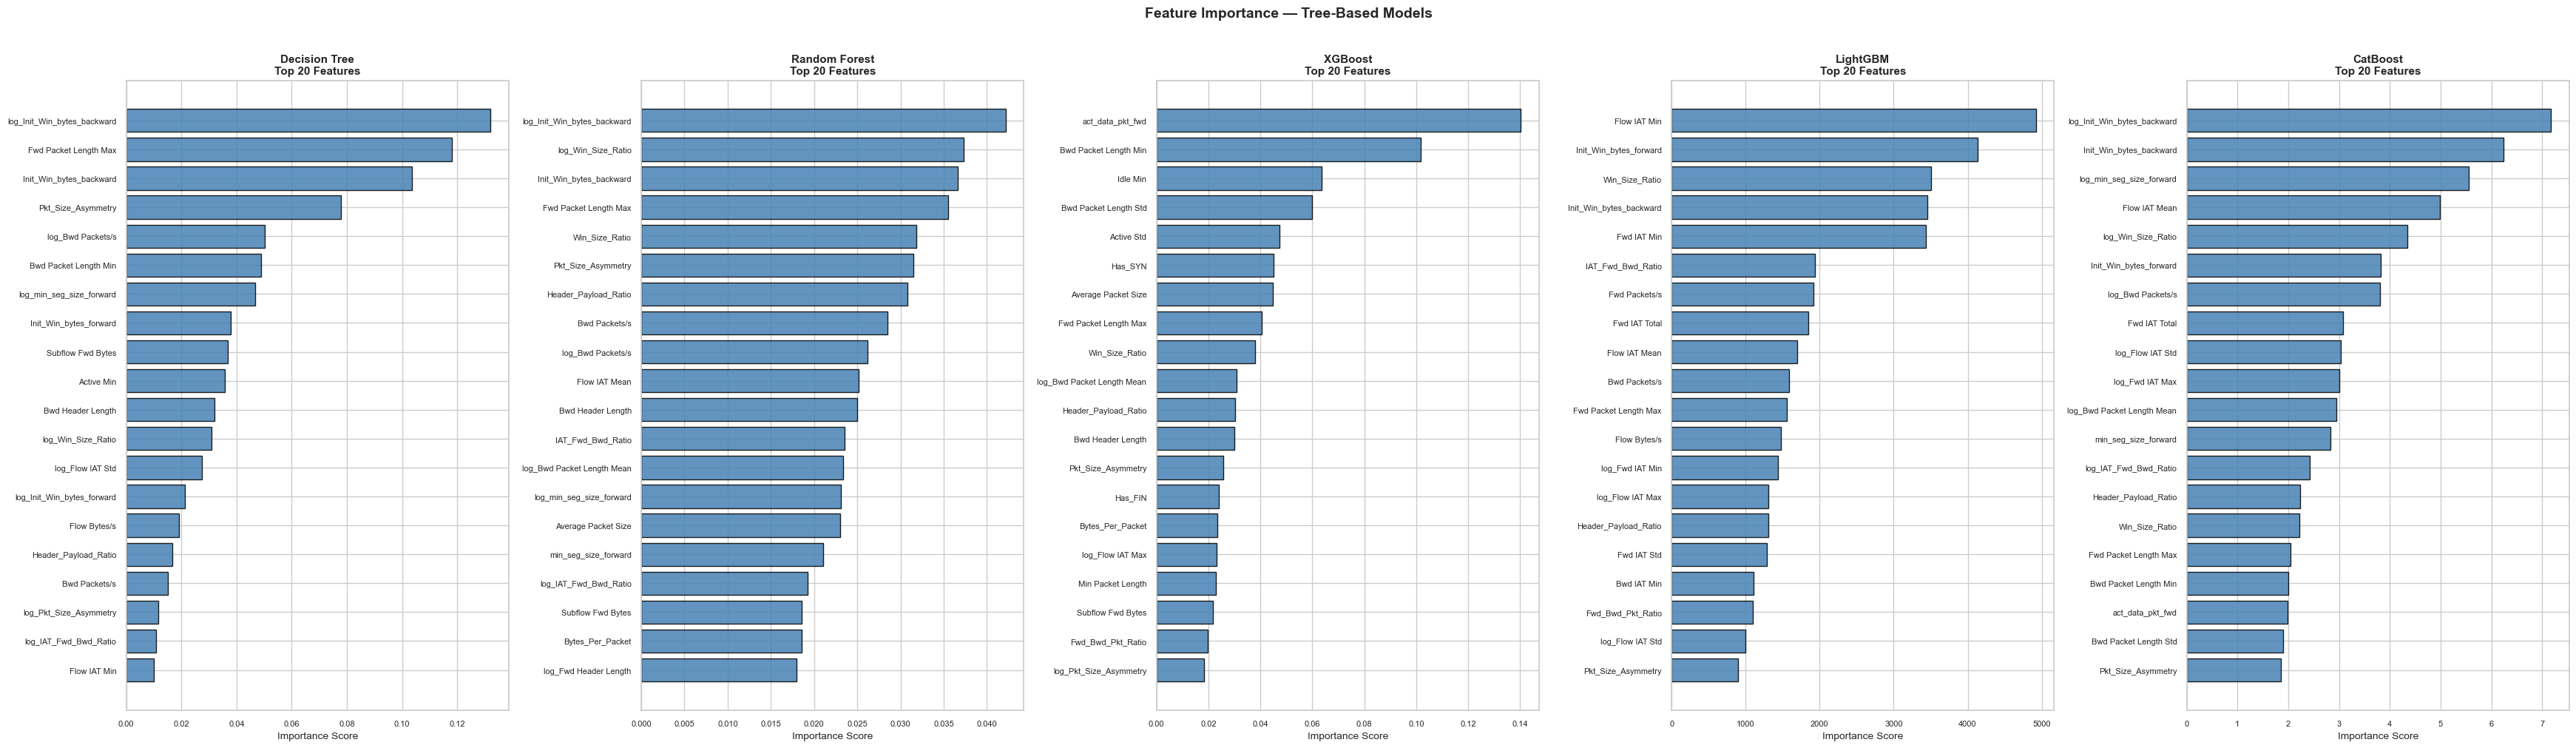

✅ Saved to feature_importance.png


In [46]:
tree_models = ['Decision Tree','Random Forest','XGBoost','LightGBM','CatBoost']
tree_models = [m for m in tree_models if m in trained]

fig, axes = plt.subplots(1, len(tree_models),
                         figsize=(7 * len(tree_models), 10))
if len(tree_models) == 1:
    axes = [axes]

feat_names = (FEATURE_COLS if 'FEATURE_COLS' in dir()
              else [f'Feature_{i}' for i in range(X_resampled.shape[1])])

for ax, name in zip(axes, tree_models):
    model = trained[name]

    # Get importances
    if hasattr(model, 'feature_importances_'):
        imps = model.feature_importances_
    else:
        ax.set_visible(False)
        continue

    imp_df = pd.DataFrame({'Feature': feat_names,
                           'Importance': imps})\
               .sort_values('Importance', ascending=True)\
               .tail(20)

    ax.barh(imp_df['Feature'], imp_df['Importance'],
            color='steelblue', edgecolor='black', alpha=0.85)
    ax.set_title(f'{name}\nTop 20 Features',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Importance Score')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Feature Importance — Tree-Based Models',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved to feature_importance.png')


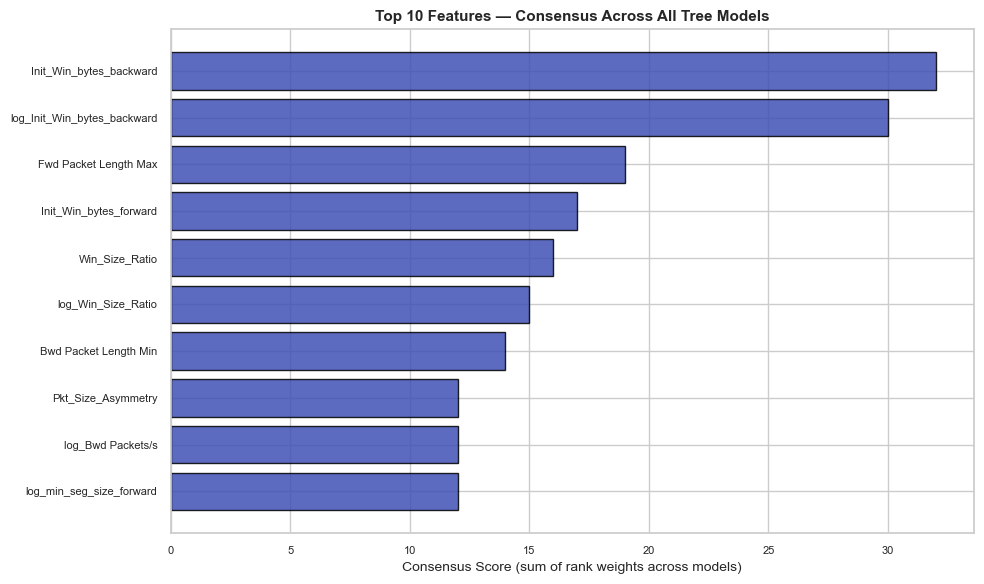

Consensus top features:
   1. Init_Win_bytes_backward                       score=32
   2. log_Init_Win_bytes_backward                   score=30
   3. Fwd Packet Length Max                         score=19
   4. Init_Win_bytes_forward                        score=17
   5. Win_Size_Ratio                                score=16
   6. log_Win_Size_Ratio                            score=15
   7. Bwd Packet Length Min                         score=14
   8. Pkt_Size_Asymmetry                            score=12
   9. log_Bwd Packets/s                             score=12
  10. log_min_seg_size_forward                      score=12


In [47]:
# ── Top 10 features agreed on by all tree models (consensus)
top_n = 10
feat_rank = {}
for name in tree_models:
    model = trained[name]
    if not hasattr(model, 'feature_importances_'):
        continue
    imps = model.feature_importances_
    ranked = pd.Series(imps, index=feat_names)\
               .sort_values(ascending=False)
    for rank, feat in enumerate(ranked.index[:top_n]):
        feat_rank[feat] = feat_rank.get(feat, 0) + (top_n - rank)

consensus = pd.Series(feat_rank).sort_values(ascending=False).head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(consensus.index[::-1], consensus.values[::-1],
         color='#3F51B5', edgecolor='black', alpha=0.85)
plt.xlabel('Consensus Score (sum of rank weights across models)')
plt.title(f'Top {top_n} Features — Consensus Across All Tree Models',
          fontweight='bold')
plt.tight_layout()
plt.savefig('feature_consensus.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Consensus top features:')
for i, (feat, score) in enumerate(consensus.items(), 1):
    print(f'  {i:2d}. {feat:<45} score={int(score)}')


9. Final Recommendation

In [48]:
print('='*70)
print('         FINAL MODEL EVALUATION SUMMARY')
print('='*70)

# ── Rank models by Macro F1 (best metric for imbalanced multi-class)
rank_metric = 'Macro F1'
ranking = sorted(
    model_names,
    key=lambda m: float(results[m][rank_metric])
                  if results[m][rank_metric] != 'N/A' else 0,
    reverse=True
)

print(f'\nRanking by {rank_metric} (best metric for imbalanced multi-class):')
for rank, name in enumerate(ranking, 1):
    macro_f1 = results[name]['Macro F1']
    acc      = results[name]['Accuracy']
    wf1      = results[name]['Weighted F1']
    t        = results[name]['Train Time (s)']
    star     = '  ★ BEST' if rank == 1 else ''
    print(f'  {rank}. {name:<22} '
          f'Macro F1={macro_f1:.2f}%  '
          f'Acc={acc:.2f}%  '
          f'W-F1={wf1:.2f}%  '
          f'Time={t:.1f}s{star}')

best_model_name = ranking[0]
best_model      = trained[best_model_name]

print(f'\n✅ Best Model: {best_model_name}')
print(f'   Accuracy        : {results[best_model_name]["Accuracy"]:.3f}%')
print(f'   Weighted F1     : {results[best_model_name]["Weighted F1"]:.3f}%')
print(f'   Macro F1        : {results[best_model_name]["Macro F1"]:.3f}%')
print(f'   Weighted Recall : {results[best_model_name]["Weighted Recall"]:.3f}%')
roc = results[best_model_name]['ROC-AUC (macro)']
print(f'   ROC-AUC (macro) : {roc}')

print(f'\n💡 Why Macro F1 is the right metric here:')
print(f'   - Accuracy can be misleadingly high on imbalanced data')
print(f'   - Macro F1 gives equal weight to ALL classes including rare ones')
print(f'   - A model with high Macro F1 detects Heartbleed AND DoS equally well')

# Save best model
joblib.dump(best_model, f'best_model_{best_model_name.replace(" ","_")}.pkl')
print(f'\n✅ Best model saved to '
      f'best_model_{best_model_name.replace(" ","_")}.pkl')
print('='*70)
print('\n📌 NEXT STEPS:')
print('   1. Hyperparameter tuning on top 2 models')
print('   2. Cross-validation (StratifiedKFold)')
print('   3. Final model deployment / inference pipeline')
print('='*70)


         FINAL MODEL EVALUATION SUMMARY

Ranking by Macro F1 (best metric for imbalanced multi-class):
  1. XGBoost                Macro F1=87.81%  Acc=99.82%  W-F1=99.83%  Time=161.5s  ★ BEST
  2. Random Forest          Macro F1=87.20%  Acc=99.83%  W-F1=99.83%  Time=42.6s
  3. Decision Tree          Macro F1=77.31%  Acc=99.71%  W-F1=99.73%  Time=26.9s
  4. CatBoost               Macro F1=61.67%  Acc=97.90%  W-F1=98.49%  Time=538.1s
  5. LightGBM               Macro F1=0.48%  Acc=0.78%  W-F1=1.05%  Time=99.6s

✅ Best Model: XGBoost
   Accuracy        : 99.818%
   Weighted F1     : 99.828%
   Macro F1        : 87.807%
   Weighted Recall : 99.818%
   ROC-AUC (macro) : 99.962

💡 Why Macro F1 is the right metric here:
   - Accuracy can be misleadingly high on imbalanced data
   - Macro F1 gives equal weight to ALL classes including rare ones
   - A model with high Macro F1 detects Heartbleed AND DoS equally well

✅ Best model saved to best_model_XGBoost.pkl

📌 NEXT STEPS:
   1. Hyperparame

=============================== HYPERPARAMETER TUNING OF THE TOP TWO BEST MODEL; RANDOM FOREST & XGBOOST ======================

In [49]:
from sklearn.model_selection import (RandomizedSearchCV,
                                     StratifiedKFold, cross_val_score)
from sklearn.metrics         import (accuracy_score, f1_score,
                                     precision_score, recall_score,
                                     classification_report,
                                     confusion_matrix)
from scipy.stats             import randint, uniform

In [50]:
BASELINE = {
    'Random Forest': {
        'Accuracy'   : results['Random Forest']['Accuracy'],
        'Weighted F1': results['Random Forest']['Weighted F1'],
        'Macro F1'   : results['Random Forest']['Macro F1'],
        'Recall'     : results['Random Forest']['Weighted Recall'],
    },
    'XGBoost': {
        'Accuracy'   : results['XGBoost']['Accuracy'],
        'Weighted F1': results['XGBoost']['Weighted F1'],
        'Macro F1'   : results['XGBoost']['Macro F1'],
        'Recall'     : results['XGBoost']['Weighted Recall'],
    }
}

print('Baseline scores (before tuning):')
for model, metrics in BASELINE.items():
    print(f'\n  {model}')
    for metric, val in metrics.items():
        print(f'    {metric:<15}: {val:.3f}%')


Baseline scores (before tuning):

  Random Forest
    Accuracy       : 99.826%
    Weighted F1    : 99.830%
    Macro F1       : 87.201%
    Recall         : 99.826%

  XGBoost
    Accuracy       : 99.818%
    Weighted F1    : 99.828%
    Macro F1       : 87.807%
    Recall         : 99.818%


In [51]:
# ── Cross-validation setup
# Use StratifiedKFold to preserve class proportions in each fold
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# ── Scoring metric: macro F1 (best for imbalanced multi-class)
SCORING = 'f1_macro'

print('Cross-validation strategy:')
print(f'  Method  : StratifiedKFold')
print(f'  Folds   : 3')
print(f'  Scoring : {SCORING}')
print(f'  Data    : X_resampled ({X_resampled.shape[0]:,} rows × {X_resampled.shape[1]} features)')


Cross-validation strategy:
  Method  : StratifiedKFold
  Folds   : 3
  Scoring : f1_macro
  Data    : X_resampled (521,474 rows × 69 features)


2. Random Forest — Parameter Grid & Search 
|     Parameter       |     What it controls              |             Effect                     |
|---------------------|-----------------------------------|----------------------------------------|
| `n_estimators`      | Number of trees                   | More = better accuracy but slower      |
| `max_depth`         | How deep each tree can grow       | Deeper = more complex, risk of overfit |
| `min_samples_split` | Min samples to split a node       | Higher = simpler trees, less overfit   |
| `min_samples_leaf`  | Min samples at a leaf             | Higher = smoother decision boundaries  |
| `max_features`      | Features considered at each split | Lower = more diverse trees             |
| `max_samples`       | Fraction of data per tree         | Controls memory and speed              |

In [52]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint

# ── Reduced param grid — fewer options = faster search
rf_param_grid_fast = {
    'n_estimators'     : [50, 100, 150],
    'max_depth'        : [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
    'class_weight'     : ['balanced'],
}

# ── Use smaller sample for tuning only
# Take a 20% stratified sample — enough to find good parameters
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.80, random_state=42)
tune_idx, _ = next(sss.split(X_resampled, y_resampled))

# ── Fix: use .iloc if DataFrame, direct indexing if numpy array
if hasattr(X_resampled, 'iloc'):
    # X_resampled is a DataFrame → use iloc
    X_tune = X_resampled.iloc[tune_idx].values
    print('X_resampled is a DataFrame → used .iloc[]')
else:
    # X_resampled is a numpy array → direct indexing works
    X_tune = X_resampled[tune_idx]
    print('X_resampled is a numpy array → used direct indexing')

y_tune = y_resampled[tune_idx]

print(f'Tuning sample size : {X_tune.shape[0]:,} rows')
print(f'Full training size : {X_resampled.shape[0] if hasattr(X_resampled, "shape") else len(X_resampled):,} rows')

# ── Fast CV — 2 folds instead of 3
CV_FAST = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    warm_start=False
)

rf_search = RandomizedSearchCV(
    estimator           = rf_base,
    param_distributions = rf_param_grid_fast,
    n_iter              = 10,        # 10 × 2 folds = 20 fits
    scoring             = 'f1_macro',
    cv                  = CV_FAST,
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 2,
    return_train_score  = True
)

print('\nStarting fast RF search (20 fits on 20% sample)...')
print('Expected time: 5–15 minutes\n')

start_rf = time.time()
rf_search.fit(X_tune, y_tune)         # ← tune on SAMPLE, not full data
rf_search_time = time.time() - start_rf

print(f'\n✅ RF search done in {rf_search_time/60:.1f} minutes')
print(f'Best CV Macro F1 : {rf_search.best_score_*100:.3f}%')
print(f'Best params      : {rf_search.best_params_}')

X_resampled is a DataFrame → used .iloc[]
Tuning sample size : 104,294 rows
Full training size : 521,474 rows

Starting fast RF search (20 fits on 20% sample)...
Expected time: 5–15 minutes

Fitting 2 folds for each of 10 candidates, totalling 20 fits

✅ RF search done in 1.8 minutes
Best CV Macro F1 : 96.771%
Best params      : {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}


3. Random Forest — Best Parameters & Evaluation

In [53]:
# ── Best parameters found
print('Best Random Forest Parameters:')
for param, val in rf_search.best_params_.items():
    print(f'  {param:<22}: {val}')
print(f'\nBest CV Macro F1 : {rf_search.best_score_*100:.3f}%')


Best Random Forest Parameters:
  n_estimators          : 100
  min_samples_split     : 2
  min_samples_leaf      : 1
  max_features          : sqrt
  max_depth             : None
  class_weight          : balanced

Best CV Macro F1 : 96.771%


In [54]:
# ── CV results — all 20 iterations
rf_cv_results = pd.DataFrame(rf_search.cv_results_)
rf_cv_results = rf_cv_results.sort_values('mean_test_score', ascending=False)

print('Top 10 parameter combinations (by CV Macro F1):')
display_cols = ['mean_test_score','std_test_score','mean_train_score','mean_fit_time']
display_cols = [c for c in display_cols if c in rf_cv_results.columns]
print(rf_cv_results[display_cols].head(10).round(4).to_string())


Top 10 parameter combinations (by CV Macro F1):
   mean_test_score  std_test_score  mean_train_score  mean_fit_time
1           0.9677          0.0002            0.9999        35.3837
3           0.9665          0.0017            0.9984        35.3076
9           0.9649          0.0008            0.9940        12.4761
4           0.9630          0.0016            0.9906        26.7647
2           0.9619          0.0008            0.9862        46.9847
0           0.9591          0.0010            0.9831        38.5545
8           0.9579          0.0019            0.9807        17.9680
6           0.9576          0.0016            0.9808        37.6876
5           0.9136          0.0001            0.9251        33.6350
7           0.9070          0.0021            0.9162        14.0376


In [55]:
# ── Evaluate best RF on test set
best_rf = rf_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test_scaled)

rf_tuned_acc  = accuracy_score(y_test_multi, y_pred_rf_tuned)
rf_tuned_f1w  = f1_score(y_test_multi, y_pred_rf_tuned, average='weighted', zero_division=0)
rf_tuned_f1m  = f1_score(y_test_multi, y_pred_rf_tuned, average='macro',    zero_division=0)
rf_tuned_prec = precision_score(y_test_multi, y_pred_rf_tuned, average='weighted', zero_division=0)
rf_tuned_rec  = recall_score(y_test_multi, y_pred_rf_tuned,    average='weighted', zero_division=0)

print('=== Tuned Random Forest — Test Set Results ===')
print(f'  Accuracy        : {rf_tuned_acc*100:.3f}%')
print(f'  Weighted F1     : {rf_tuned_f1w*100:.3f}%')
print(f'  Macro F1        : {rf_tuned_f1m*100:.3f}%')
print(f'  Precision (W)   : {rf_tuned_prec*100:.3f}%')
print(f'  Recall (W)      : {rf_tuned_rec*100:.3f}%')

print(f'\n  Improvement over baseline:')
print(f'  Macro F1 : {BASELINE["Random Forest"]["Macro F1"]:.3f}% → {rf_tuned_f1m*100:.3f}%  '
      f'(+{rf_tuned_f1m*100 - BASELINE["Random Forest"]["Macro F1"]:.3f}%)')
print(f'  Accuracy : {BASELINE["Random Forest"]["Accuracy"]:.3f}% → {rf_tuned_acc*100:.3f}%  '
      f'(+{rf_tuned_acc*100 - BASELINE["Random Forest"]["Accuracy"]:.3f}%)')


=== Tuned Random Forest — Test Set Results ===
  Accuracy        : 99.766%
  Weighted F1     : 99.775%
  Macro F1        : 85.067%
  Precision (W)   : 99.791%
  Recall (W)      : 99.766%

  Improvement over baseline:
  Macro F1 : 87.201% → 85.067%  (+-2.134%)
  Accuracy : 99.826% → 99.766%  (+-0.060%)


In [56]:
# ── Classification report — tuned RF
CLASS_NAMES = [str(c) for c in le.classes_]
print('Classification Report — Tuned Random Forest:')
print(classification_report(
    y_test_multi, y_pred_rf_tuned,
    target_names=CLASS_NAMES, zero_division=0
))


Classification Report — Tuned Random Forest:
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    414500
                     Bot       0.63      0.97      0.76       390
                    DDoS       1.00      1.00      1.00     25603
           DoS GoldenEye       0.99      1.00      0.99      2057
                DoS Hulk       0.99      1.00      1.00     34569
        DoS Slowhttptest       0.92      0.99      0.95      1046
           DoS slowloris       0.99      0.98      0.99      1077
             FTP-Patator       1.00      1.00      1.00      1186
              Heartbleed       0.67      1.00      0.80         2
            Infiltration       1.00      0.86      0.92         7
                PortScan       0.99      1.00      0.99     18139
             SSH-Patator       0.99      0.99      0.99       644
  Web Attack_Brute Force       0.70      0.66      0.68       294
Web Attack_Sql Injection      

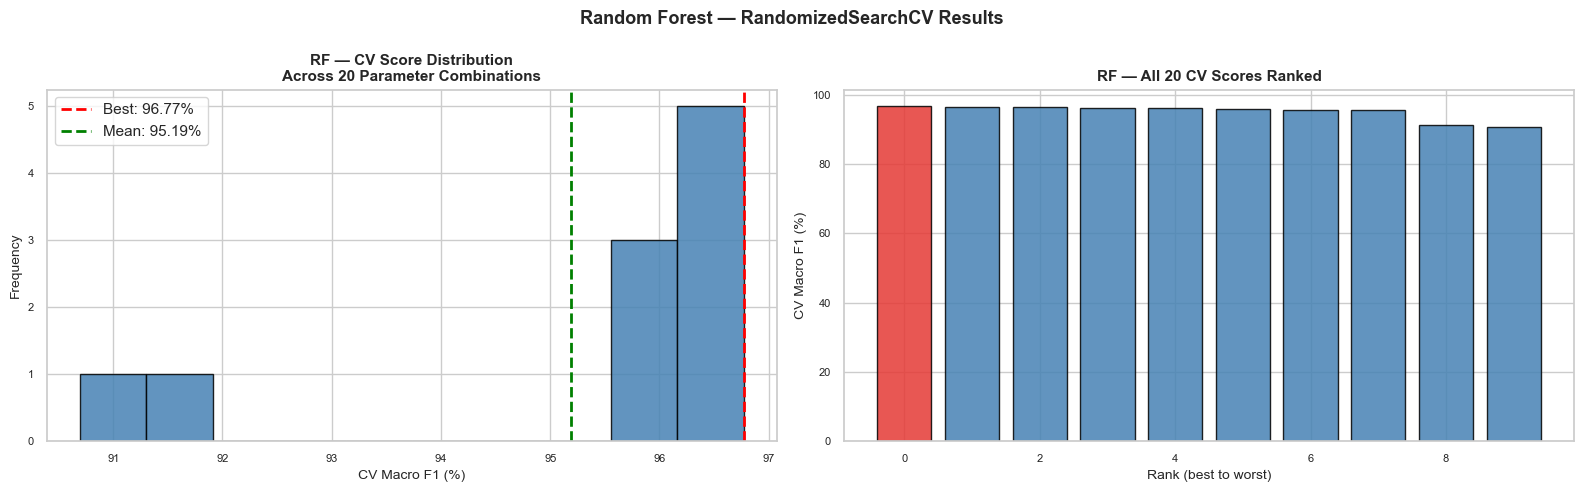

✅ Saved to rf_tuning_results.png


In [57]:
# ── Visualise CV score progression
cv_scores = rf_cv_results['mean_test_score'].values * 100
cv_std    = rf_cv_results['std_test_score'].values  * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Score distribution
axes[0].hist(cv_scores, bins=10, color='steelblue',
             edgecolor='black', alpha=0.85)
axes[0].axvline(cv_scores.max(), color='red', linestyle='--',
                linewidth=2, label=f'Best: {cv_scores.max():.2f}%')
axes[0].axvline(cv_scores.mean(), color='green', linestyle='--',
                linewidth=2, label=f'Mean: {cv_scores.mean():.2f}%')
axes[0].set_xlabel('CV Macro F1 (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('RF — CV Score Distribution\nAcross 20 Parameter Combinations',
                  fontweight='bold')
axes[0].legend()

# Sorted scores
sorted_scores = np.sort(cv_scores)[::-1]
axes[1].bar(range(len(sorted_scores)), sorted_scores,
            color=['#E53935' if i==0 else 'steelblue'
                   for i in range(len(sorted_scores))],
            edgecolor='black', alpha=0.85)
axes[1].set_xlabel('Rank (best to worst)')
axes[1].set_ylabel('CV Macro F1 (%)')
axes[1].set_title('RF — All 20 CV Scores Ranked',
                  fontweight='bold')

plt.suptitle('Random Forest — RandomizedSearchCV Results',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_tuning_results.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved to rf_tuning_results.png')


4. XGBoost — Parameter Grid & Search
| Parameter          | What it controls             | Effect                                |
|--------------------|------------------------------|---------------------------------------|
| `n_estimators`     | Number of boosting rounds    | More = better fit, risk of overfit    |
| `max_depth`        | Max depth per tree           | Deeper = more complex                 |
| `learning_rate`    | Step size per round          | Lower = more robust, needs more trees |
| `subsample`        | Row fraction per tree        | Lower = less overfit                  |
| `colsample_bytree` | Feature fraction per tree    | Lower = more diverse trees            |
| `min_child_weight` | Min sum of weights in a leaf | Higher = more conservative            |
| `gamma`            | Min loss reduction to split  | Higher = more conservative            |
| `reg_alpha`        | L1 regularisation            | Pushes weights to zero                |
| `reg_lambda`       | L2 regularisation            | Shrinks weights                       |

In [58]:
# ── Convert to numpy to avoid pandas indexing issues
X_res_np = X_resampled.values if hasattr(X_resampled, 'values') else X_resampled
y_res_np = y_resampled

# ── Take 20% stratified sample for tuning only
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.80, random_state=42)
tune_idx, _ = next(sss.split(X_res_np, y_res_np))

X_tune = X_res_np[tune_idx]
y_tune = y_res_np[tune_idx]

print(f'Tuning sample : {X_tune.shape[0]:,} rows')
print(f'Full data     : {X_res_np.shape[0]:,} rows')

# ── Reduced param grid for speed
xgb_param_grid_fast = {
    'n_estimators'    : [50, 100, 150],
    'max_depth'       : [3, 5, 6, 8],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.6, 0.8, 1.0],
    'colsample_bytree': [0.5, 0.7, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma'           : [0, 0.1, 0.3],
    'reg_alpha'       : [0, 0.1, 0.5],
    'reg_lambda'      : [0.5, 1.0, 2.0],
}

# ── Fast CV — 2 folds
CV_FAST = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42,
    verbosity=0,
    tree_method='hist'    # ← fastest tree method for large data
)

xgb_search = RandomizedSearchCV(
    estimator           = xgb_base,
    param_distributions = xgb_param_grid_fast,
    n_iter              = 10,       # 10 × 2 folds = 20 fits
    scoring             = 'f1_macro',
    cv                  = CV_FAST,
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 2,
    return_train_score  = True
)

print('\nStarting fast XGBoost search (20 fits on 20% sample)...')
print('Expected time: 3–10 minutes\n')

start_xgb = time.time()
xgb_search.fit(X_tune, y_tune)       # ← tune on sample
xgb_search_time = time.time() - start_xgb

print(f'\n✅ XGBoost search done in {xgb_search_time/60:.1f} minutes')
print(f'Best CV Macro F1 : {xgb_search.best_score_*100:.3f}%')
print(f'Best params      : {xgb_search.best_params_}')

Tuning sample : 104,294 rows
Full data     : 521,474 rows

Starting fast XGBoost search (20 fits on 20% sample)...
Expected time: 3–10 minutes

Fitting 2 folds for each of 10 candidates, totalling 20 fits

✅ XGBoost search done in 2.5 minutes
Best CV Macro F1 : 95.472%
Best params      : {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0.5, 'n_estimators': 50, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.2, 'gamma': 0.3, 'colsample_bytree': 0.5}


In [59]:
# ── Retrain best params on FULL data
best_xgb = XGBClassifier(
    **xgb_search.best_params_,
    use_label_encoder=False,
    eval_metric='mlogloss',
    tree_method='hist',
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

print('Retraining best XGBoost on full data...')
best_xgb.fit(X_res_np, y_res_np)
print('✅ Done')

# ── Evaluate on test set
X_test_np = X_test_scaled.values if hasattr(X_test_scaled, 'values') else X_test_scaled

y_pred_xgb_tuned  = best_xgb.predict(X_test_np)
xgb_tuned_acc     = accuracy_score(y_test_multi, y_pred_xgb_tuned)
xgb_tuned_f1m     = f1_score(y_test_multi, y_pred_xgb_tuned,
                              average='macro', zero_division=0)
xgb_tuned_f1w     = f1_score(y_test_multi, y_pred_xgb_tuned,
                              average='weighted', zero_division=0)
xgb_tuned_rec     = recall_score(y_test_multi, y_pred_xgb_tuned,
                                  average='weighted', zero_division=0)
xgb_tuned_prec    = precision_score(y_test_multi, y_pred_xgb_tuned,
                                     average='weighted', zero_division=0)

print(f'\nTest Accuracy   : {xgb_tuned_acc*100:.3f}%')
print(f'Test Macro F1   : {xgb_tuned_f1m*100:.3f}%')
print(f'Test Weighted F1: {xgb_tuned_f1w*100:.3f}%')
print(f'Test Recall (W) : {xgb_tuned_rec*100:.3f}%')

Retraining best XGBoost on full data...
✅ Done

Test Accuracy   : 99.794%
Test Macro F1   : 82.977%
Test Weighted F1: 99.806%
Test Recall (W) : 99.794%


5. XGBoost — Best Parameters & Evaluation

In [60]:
# ── Best parameters found
print('Best XGBoost Parameters:')
for param, val in xgb_search.best_params_.items():
    print(f'  {param:<22}: {val}')
print(f'\nBest CV Macro F1 : {xgb_search.best_score_*100:.3f}%')


Best XGBoost Parameters:
  subsample             : 0.8
  reg_lambda            : 2.0
  reg_alpha             : 0.5
  n_estimators          : 50
  min_child_weight      : 3
  max_depth             : 6
  learning_rate         : 0.2
  gamma                 : 0.3
  colsample_bytree      : 0.5

Best CV Macro F1 : 95.472%


In [61]:
# ── CV results — all 10 iterations
xgb_cv_results = pd.DataFrame(xgb_search.cv_results_)
xgb_cv_results = xgb_cv_results.sort_values('mean_test_score', ascending=False)

print('Top 10 parameter combinations (by CV Macro F1):')
display_cols = ['mean_test_score','std_test_score','mean_train_score','mean_fit_time']
display_cols = [c for c in display_cols if c in xgb_cv_results.columns]
print(xgb_cv_results[display_cols].head(10).round(4).to_string())


Top 10 parameter combinations (by CV Macro F1):
   mean_test_score  std_test_score  mean_train_score  mean_fit_time
2           0.9547          0.0004            0.9718        28.5048
7           0.9538          0.0013            0.9646        66.9509
9           0.9515          0.0007            0.9636        31.6614
3           0.9513          0.0026            0.9690        58.8405
5           0.9471          0.0036            0.9575        27.1877
4           0.9409          0.0014            0.9480        26.2786
8           0.9364          0.0001            0.9443        54.1371
1           0.9295          0.0019            0.9378        46.3553
6           0.9165          0.0012            0.9255        73.5720
0           0.6906          0.0063            0.6930        27.0240


In [62]:
# ── Evaluate best XGBoost on test set
best_xgb = xgb_search.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test_scaled)

xgb_tuned_acc  = accuracy_score(y_test_multi, y_pred_xgb_tuned)
xgb_tuned_f1w  = f1_score(y_test_multi, y_pred_xgb_tuned, average='weighted', zero_division=0)
xgb_tuned_f1m  = f1_score(y_test_multi, y_pred_xgb_tuned, average='macro',    zero_division=0)
xgb_tuned_prec = precision_score(y_test_multi, y_pred_xgb_tuned, average='weighted', zero_division=0)
xgb_tuned_rec  = recall_score(y_test_multi, y_pred_xgb_tuned,    average='weighted', zero_division=0)

print('=== Tuned XGBoost — Test Set Results ===')
print(f'  Accuracy        : {xgb_tuned_acc*100:.3f}%')
print(f'  Weighted F1     : {xgb_tuned_f1w*100:.3f}%')
print(f'  Macro F1        : {xgb_tuned_f1m*100:.3f}%')
print(f'  Precision (W)   : {xgb_tuned_prec*100:.3f}%')
print(f'  Recall (W)      : {xgb_tuned_rec*100:.3f}%')

print(f'\n  Improvement over baseline:')
print(f'  Macro F1 : {BASELINE["XGBoost"]["Macro F1"]:.3f}% → {xgb_tuned_f1m*100:.3f}%  '
      f'(+{xgb_tuned_f1m*100 - BASELINE["XGBoost"]["Macro F1"]:.3f}%)')
print(f'  Accuracy : {BASELINE["XGBoost"]["Accuracy"]:.3f}% → {xgb_tuned_acc*100:.3f}%  '
      f'(+{xgb_tuned_acc*100 - BASELINE["XGBoost"]["Accuracy"]:.3f}%)')


=== Tuned XGBoost — Test Set Results ===
  Accuracy        : 99.740%
  Weighted F1     : 99.757%
  Macro F1        : 82.130%
  Precision (W)   : 99.789%
  Recall (W)      : 99.740%

  Improvement over baseline:
  Macro F1 : 87.807% → 82.130%  (+-5.677%)
  Accuracy : 99.818% → 99.740%  (+-0.078%)


In [63]:
# ── Classification report — tuned XGBoost
print('Classification Report — Tuned XGBoost:')
print(classification_report(
    y_test_multi, y_pred_xgb_tuned,
    target_names=CLASS_NAMES, zero_division=0
))


Classification Report — Tuned XGBoost:
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    414500
                     Bot       0.52      0.97      0.68       390
                    DDoS       1.00      1.00      1.00     25603
           DoS GoldenEye       0.98      0.99      0.99      2057
                DoS Hulk       0.99      1.00      1.00     34569
        DoS Slowhttptest       0.89      0.98      0.93      1046
           DoS slowloris       0.99      0.98      0.98      1077
             FTP-Patator       0.99      1.00      0.99      1186
              Heartbleed       1.00      1.00      1.00         2
            Infiltration       0.16      0.86      0.27         7
                PortScan       0.99      1.00      0.99     18139
             SSH-Patator       0.98      0.99      0.98       644
  Web Attack_Brute Force       0.81      0.64      0.71       294
Web Attack_Sql Injection       0.17 

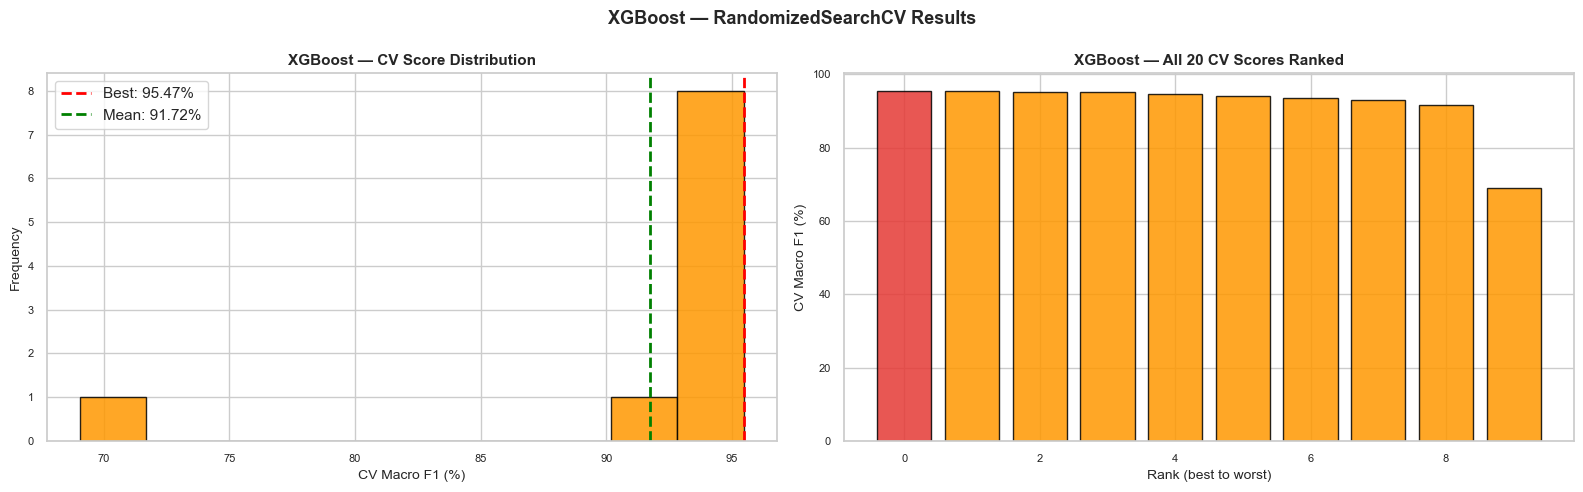

✅ Saved to xgb_tuning_results.png


In [64]:
# ── XGBoost CV score visualisation
xgb_cv_scores = xgb_cv_results['mean_test_score'].values * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(xgb_cv_scores, bins=10, color='#FF9800',
             edgecolor='black', alpha=0.85)
axes[0].axvline(xgb_cv_scores.max(), color='red', linestyle='--',
                linewidth=2, label=f'Best: {xgb_cv_scores.max():.2f}%')
axes[0].axvline(xgb_cv_scores.mean(), color='green', linestyle='--',
                linewidth=2, label=f'Mean: {xgb_cv_scores.mean():.2f}%')
axes[0].set_xlabel('CV Macro F1 (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('XGBoost — CV Score Distribution',fontweight='bold')
axes[0].legend()

sorted_xgb = np.sort(xgb_cv_scores)[::-1]
axes[1].bar(range(len(sorted_xgb)), sorted_xgb,
            color=['#E53935' if i==0 else '#FF9800'
                   for i in range(len(sorted_xgb))],
            edgecolor='black', alpha=0.85)
axes[1].set_xlabel('Rank (best to worst)')
axes[1].set_ylabel('CV Macro F1 (%)')
axes[1].set_title('XGBoost — All 20 CV Scores Ranked', fontweight='bold')

plt.suptitle('XGBoost — RandomizedSearchCV Results',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_tuning_results.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved to xgb_tuning_results.png')


6. Before vs After Tuning Comparison

In [65]:
metrics_to_compare = ['Accuracy','Weighted F1','Macro F1','Recall']

compare_data = {
    'RF Baseline'  : BASELINE['Random Forest'],
    'RF Tuned'     : {
        'Accuracy'   : round(rf_tuned_acc*100,  3),
        'Weighted F1': round(rf_tuned_f1w*100,  3),
        'Macro F1'   : round(rf_tuned_f1m*100,  3),
        'Recall'     : round(rf_tuned_rec*100,   3),
    },
    'XGB Baseline' : BASELINE['XGBoost'],
    'XGB Tuned'    : {
        'Accuracy'   : round(xgb_tuned_acc*100, 3),
        'Weighted F1': round(xgb_tuned_f1w*100, 3),
        'Macro F1'   : round(xgb_tuned_f1m*100, 3),
        'Recall'     : round(xgb_tuned_rec*100,  3),
    },
}

compare_df = pd.DataFrame(compare_data).T
print('Before vs After Tuning:')
print(compare_df.to_string())


Before vs After Tuning:
              Accuracy  Weighted F1  Macro F1  Recall
RF Baseline    99.8260      99.8300   87.2010 99.8260
RF Tuned       99.7660      99.7750   85.0670 99.7660
XGB Baseline   99.8180      99.8280   87.8070 99.8180
XGB Tuned      99.7400      99.7570   82.1300 99.7400


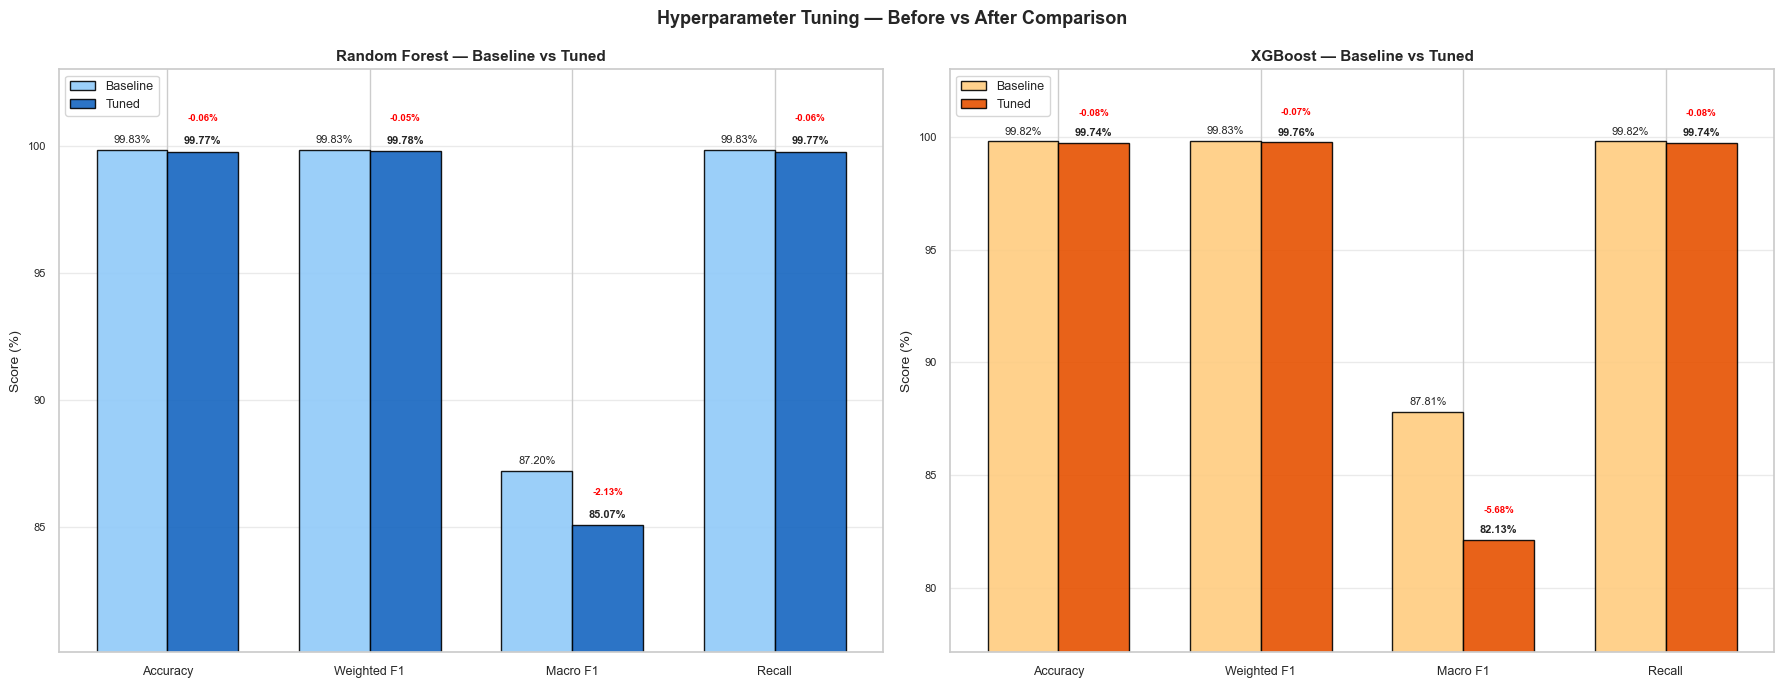

✅ Saved to tuning_comparison.png


In [66]:
# ── Side-by-side grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, model_name, base_key, tuned_key, color_base, color_tuned in [
    (axes[0], 'Random Forest', 'RF Baseline', 'RF Tuned',  '#90CAF9','#1565C0'),
    (axes[1], 'XGBoost',       'XGB Baseline','XGB Tuned', '#FFCC80','#E65100'),
]:
    base_vals  = [compare_data[base_key][m]  for m in metrics_to_compare]
    tuned_vals = [compare_data[tuned_key][m] for m in metrics_to_compare]
    x = np.arange(len(metrics_to_compare))
    w = 0.35

    bars1 = ax.bar(x - w/2, base_vals,  w, label='Baseline',
                   color=color_base,  edgecolor='black', alpha=0.9)
    bars2 = ax.bar(x + w/2, tuned_vals, w, label='Tuned',
                   color=color_tuned, edgecolor='black', alpha=0.9)

    # Annotate bars
    for bar in bars1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'{bar.get_height():.2f}%', ha='center',
                va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'{bar.get_height():.2f}%', ha='center',
                va='bottom', fontsize=8, fontweight='bold')

    # Delta arrows
    for xi, (bv, tv) in enumerate(zip(base_vals, tuned_vals)):
        delta = tv - bv
        clr   = 'green' if delta >= 0 else 'red'
        ax.annotate(f'{delta:+.2f}%',
                    xy=(xi+w/2, tv+1.2), fontsize=7,
                    color=clr, ha='center', fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(metrics_to_compare, fontsize=9)
    ax.set_ylabel('Score (%)')
    ax.set_ylim([max(0, min(base_vals+tuned_vals)-5), 103])
    ax.set_title(f'{model_name} — Baseline vs Tuned', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Hyperparameter Tuning — Before vs After Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tuning_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved to tuning_comparison.png')


7. Final Tuned Model Evaluation
Head-to-head comparison of the two tuned models to pick the overall winner.

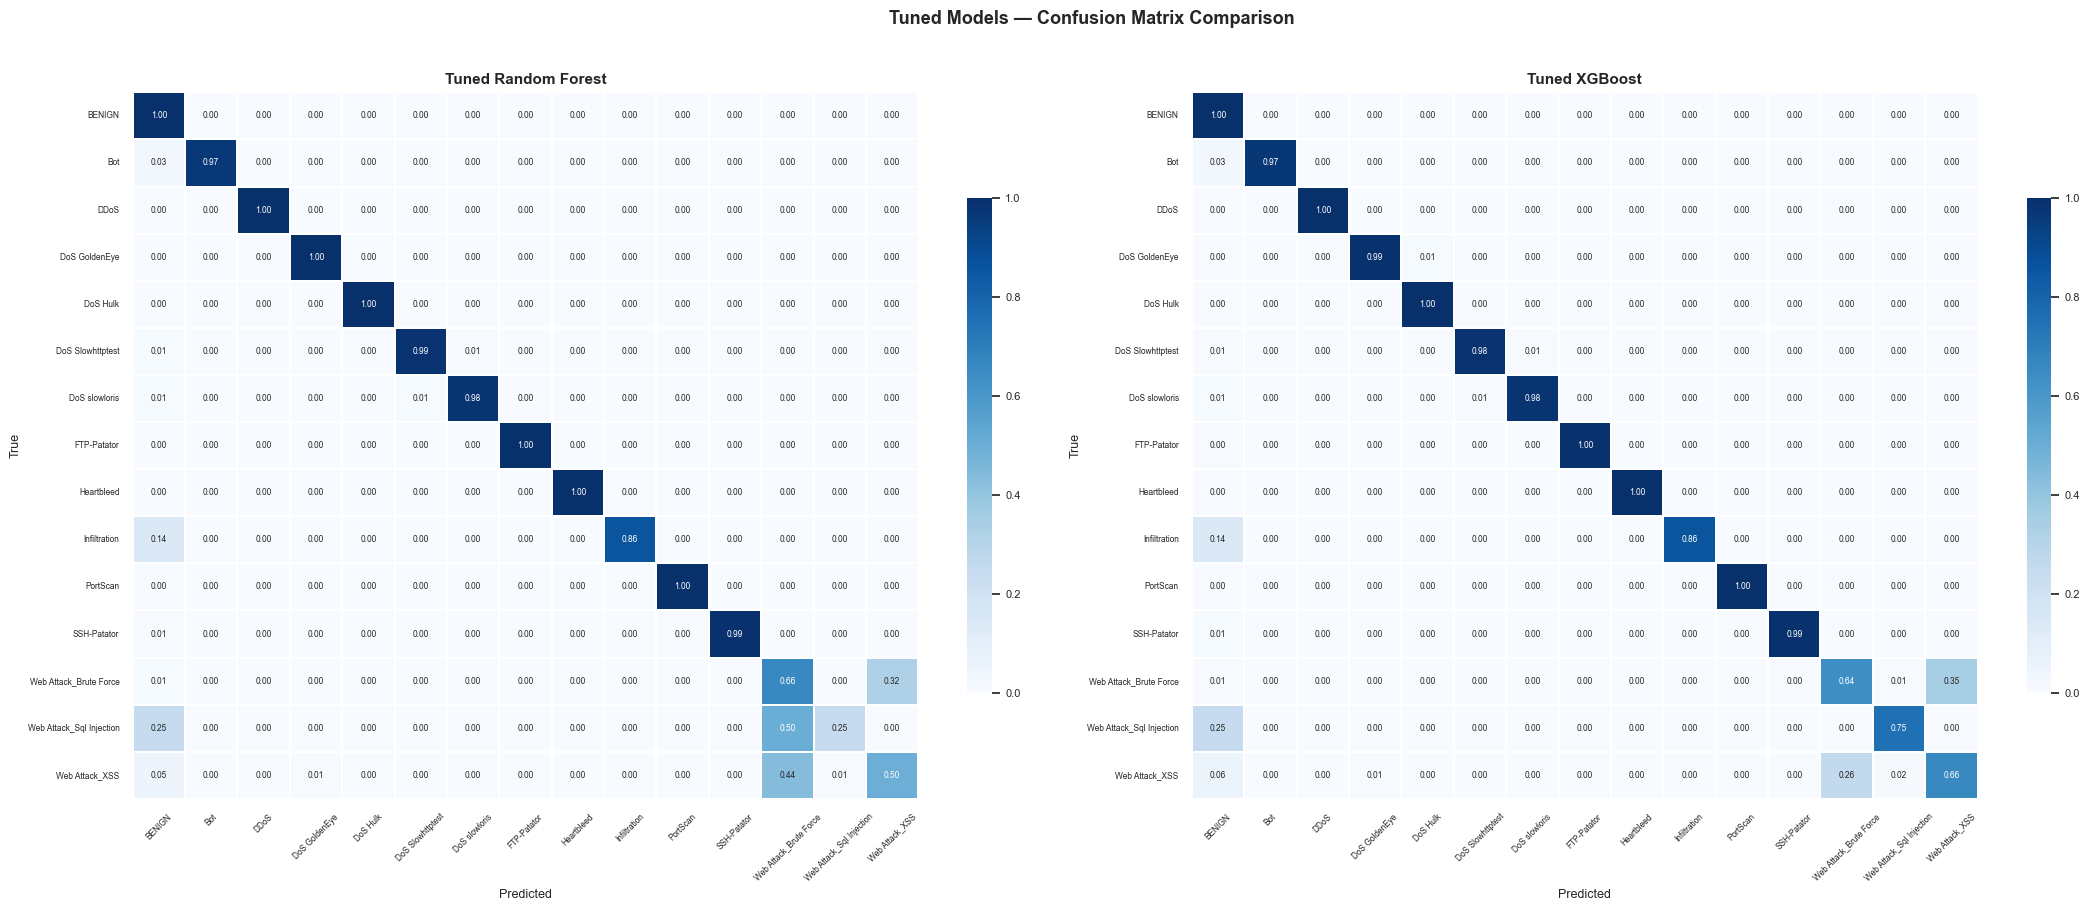

In [67]:
# ── Tuned confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, y_pred, title in [
    (axes[0], y_pred_rf_tuned,  'Tuned Random Forest'),
    (axes[1], y_pred_xgb_tuned, 'Tuned XGBoost'),
]:
    cm      = confusion_matrix(y_test_multi, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.3, annot_kws={'size':6},
                vmin=0, vmax=1, cbar_kws={'shrink':0.7})
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True',      fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    ax.tick_params(axis='y', rotation=0,  labelsize=6)

plt.suptitle('Tuned Models — Confusion Matrix Comparison',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('tuned_confusion_matrices.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


In [68]:
# ── Head-to-head summary
print('='*60)
print('     TUNED MODEL HEAD-TO-HEAD COMPARISON')
print('='*60)

metrics_hth = {
    'Accuracy (%)'    : (rf_tuned_acc*100,  xgb_tuned_acc*100),
    'Weighted F1 (%)' : (rf_tuned_f1w*100,  xgb_tuned_f1w*100),
    'Macro F1 (%)'    : (rf_tuned_f1m*100,  xgb_tuned_f1m*100),
    'Precision (W) (%)': (rf_tuned_prec*100, xgb_tuned_prec*100),
    'Recall (W) (%)'  : (rf_tuned_rec*100,  xgb_tuned_rec*100),
}

print(f'  {"Metric":<22}  {"Tuned RF":>12}  {"Tuned XGB":>12}  {"Winner":>12}')
print(f'  {"-"*60}')
rf_wins, xgb_wins = 0, 0
for metric, (rf_val, xgb_val) in metrics_hth.items():
    winner = 'RF' if rf_val > xgb_val else ('XGB' if xgb_val > rf_val else 'Tie')
    if winner == 'RF':  rf_wins  += 1
    if winner == 'XGB': xgb_wins += 1
    print(f'  {metric:<22}  {rf_val:>11.3f}%  {xgb_val:>11.3f}%  {winner:>12}')

print(f'  {"-"*60}')
print(f'  {"Wins":<22}  {rf_wins:>12}  {xgb_wins:>12}')

overall_winner = 'Random Forest' if rf_wins > xgb_wins else 'XGBoost'
print(f'\n🏆 Overall Winner: {overall_winner}')
print('   (based on most metrics won)')
print('   Use Macro F1 as the primary tiebreaker for imbalanced data')


     TUNED MODEL HEAD-TO-HEAD COMPARISON
  Metric                      Tuned RF     Tuned XGB        Winner
  ------------------------------------------------------------
  Accuracy (%)                 99.766%       99.740%            RF
  Weighted F1 (%)              99.775%       99.757%            RF
  Macro F1 (%)                 85.067%       82.130%            RF
  Precision (W) (%)            99.791%       99.789%            RF
  Recall (W) (%)               99.766%       99.740%            RF
  ------------------------------------------------------------
  Wins                               5             0

🏆 Overall Winner: Random Forest
   (based on most metrics won)
   Use Macro F1 as the primary tiebreaker for imbalanced data


8. Save Tuned Models

In [69]:
import os
OUT_DIR = 'tuned_models'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Save both tuned models
joblib.dump(best_rf,  f'{OUT_DIR}/tuned_random_forest.pkl')
joblib.dump(best_xgb, f'{OUT_DIR}/tuned_xgboost.pkl')

# ── Save search results for reference
rf_cv_results.to_csv(f'{OUT_DIR}/rf_cv_results.csv',   index=False)
xgb_cv_results.to_csv(f'{OUT_DIR}/xgb_cv_results.csv', index=False)

# ── Save best parameters
best_params = {
    'Random Forest': rf_search.best_params_,
    'XGBoost'      : xgb_search.best_params_,
}
pd.DataFrame(best_params).to_csv(f'{OUT_DIR}/best_params.csv')

print('✅ Saved to tuned_models/')
for f in os.listdir(OUT_DIR):
    size = os.path.getsize(f'{OUT_DIR}/{f}') / 1024
    print(f'   {f:<40} {size:,.1f} KB')

print('\n'+'='*60)
print('   HYPERPARAMETER TUNING COMPLETE')
print('='*60)
print(f'  RF  — Best CV Macro F1 : {rf_search.best_score_*100:.3f}%')
print(f'  XGB — Best CV Macro F1 : {xgb_search.best_score_*100:.3f}%')
print(f'  Overall Winner         : {overall_winner}')
print('\n📌 NEXT STEPS:')
print('   → Use the winning model for final predictions')
print('   → Build inference pipeline for new network traffic')
print('   → Document findings for your portfolio')
print('='*60)


✅ Saved to tuned_models/
   .ipynb_checkpoints                       4.0 KB
   best_params.csv                          0.3 KB
   rf_cv_results.csv                        4.3 KB
   tuned_random_forest.pkl                  33,254.8 KB
   tuned_xgboost.pkl                        1,028.0 KB
   xgb_cv_results.csv                       4.7 KB

   HYPERPARAMETER TUNING COMPLETE
  RF  — Best CV Macro F1 : 96.771%
  XGB — Best CV Macro F1 : 95.472%
  Overall Winner         : Random Forest

📌 NEXT STEPS:
   → Use the winning model for final predictions
   → Build inference pipeline for new network traffic
   → Document findings for your portfolio
